In [35]:
import pandas as pd
import glob as glob
import ast
import regex as re
import matplotlib.pyplot as plt

# ppe data

In [36]:
ppe_data = pd.read_excel("weo_data (2).xlsx")
ppe_data_2025 = ppe_data[["Country", "Subject Descriptor", 2025]]#.head()
ppe_data_2025
# ppe_data

,Country,Subject Descriptor,2025
0,Antigua and Barbuda,Implied PPP conversion rate,1.923
1,Argentina,Implied PPP conversion rate,532.381
2,Aruba,Implied PPP conversion rate,1.329
3,The Bahamas,Implied PPP conversion rate,0.947
4,Barbados,Implied PPP conversion rate,2.226
5,Belize,Implied PPP conversion rate,1.082
6,Bolivia,Implied PPP conversion rate,2.682
7,Brazil,Implied PPP conversion rate,2.502
8,Chile,Implied PPP conversion rate,464.988
9,Colombia,Implied PPP conversion rate,1535.671


In [37]:
countries_dict = {
    "Argentina": "Argentina",
    "Bolivia": "Bolivia",
    "Brazil": "Brasil",
    "Chile": "Chile",
    "Colombia": "Colombia",
    "Costa Rica": "Costa Rica",
    "Cuba": "Cuba",
    "Dominican Republic": "República Dominicana",
    "Ecuador": "Ecuador",
    "El Salvador": "El Salvador",
    "Guatemala": "Guatemala",
    "Honduras": "Honduras",
    "Jamaica": "Jamaica",
    "Mexico": "México",
    "Panama": "Panamá",
    "Paraguay": "Paraguay",
    "Peru": "Perú",
    "Trinidad and Tobago": "Trinidad y Tobago",
    "Uruguay": "Uruguay",
    "Venezuela": "Venezuela"
}

In [38]:
ppe_2025_ilia = ppe_data_2025[ppe_data_2025["Country"].isin(countries_dict.keys())]
ppe_2025_ilia = ppe_2025_ilia.replace({"Country": countries_dict}).sort_values("Country").reset_index(drop=True)
ppe_2025_ilia

,Country,Subject Descriptor,2025
0,Argentina,Implied PPP conversion rate,532.381
1,Bolivia,Implied PPP conversion rate,2.682
2,Brasil,Implied PPP conversion rate,2.502
3,Chile,Implied PPP conversion rate,464.988
4,Colombia,Implied PPP conversion rate,1535.671
5,Costa Rica,Implied PPP conversion rate,309.450
6,Ecuador,Implied PPP conversion rate,0.419
7,El Salvador,Implied PPP conversion rate,0.416
8,Guatemala,Implied PPP conversion rate,3.311
9,Honduras,Implied PPP conversion rate,11.612


## usd change

In [39]:
import datetime
usd_data_banco_central = pd.read_excel("TCB_510_PARIDADES.xlsx")

def matching_country(s):
    for c in countries_dict.values():
        if c in s:
            return True

    return False

usd_data_banco_central_latam = usd_data_banco_central[usd_data_banco_central["Descripción series"].apply(matching_country)]
usd_data_banco_central_latam["country"] = usd_data_banco_central_latam["Descripción series"].apply(lambda x: x.split(":")[0])
usd_data_banco_central_latam = usd_data_banco_central_latam[["country", datetime.datetime(2026, 5, 1, 0, 0)]]
usd_data_banco_central_latam = usd_data_banco_central_latam.rename(columns={datetime.datetime(2026, 5, 1, 0, 0): "conversion_value"}).reset_index(drop=True)
usd_data_banco_central_latam["to_dollar"] = usd_data_banco_central_latam["conversion_value"].apply(lambda x: 1/x)
usd_data_banco_central_latam

/tmp/ipykernel_784/455567754.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usd_data_banco_central_latam["country"] = usd_data_banco_central_latam["Descripción series"].apply(lambda x: x.split(":")[0])


,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Guatemala,7.623253,0.131178
8,México,17.303647,0.057791
9,Panamá,1.000000,1.000000


In [ ]:
usd_change_dict_missing = {
    "Argentina": 0.000716,
    "Bolivia": 1/6.9040,
    "Brasil": 0.199619,
    "Chile": 0.001113,
    "Colombia": 0.000268,
    "Costa Rica": 1/459.2476,
    "Cuba": 1/120.4819,
    "Ecuador": 1, # Usan dólar
    "El Salvador": 1, # Usan dólar
    "Guatemala": 1/7.62,
    "Honduras": 1/26.5904,
    "Jamaica": 1/157.7713,
    "México": 0.057725,
    "Panamá": 1/0.9991,
    "Paraguay": 1/6387.6011,
    "Perú": 1/3.4431,
    "República Dominicana": 1/60.0737,
    "Trinidad y Tobago": 1/6.7830,
    "Uruguay": 1/40.0989,
    "Venezuela": 1, # Usan dólar
}
print(len(usd_change_dict_missing))

20


In [41]:
for c in usd_change_dict_missing.keys():
    if c not in list(usd_data_banco_central_latam["country"]):
        if c in ["Ecuador", "El Salvador"]:
            missing_c = pd.DataFrame([{"country": c, "conversion_value": 1, "to_dollar": usd_change_dict_missing[c]}])
            usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])
            print(missing_c)
        else:
            missing_c = pd.DataFrame([{"country": c, "conversion_value": np.nan, "to_dollar": usd_change_dict_missing[c]}])
            print(missing_c)

   country  conversion_value  to_dollar
0  Ecuador                 1          1
       country  conversion_value  to_dollar
0  El Salvador                 1          1
    country  conversion_value  to_dollar
0  Honduras               NaN   0.037608
   country  conversion_value  to_dollar
0  Jamaica               NaN   0.006338
             country  conversion_value  to_dollar
0  Trinidad y Tobago               NaN   0.147427


## honduras

In [43]:
honduras_exchange = pd.read_excel("Tipo de Cambio Serie Mensual.xlsx", sheet_name="pretty_data")[["Mes", 2026]]
honduras_exchange_val = honduras_exchange.loc[4][2026]

missing_c = pd.DataFrame([{"country": "Honduras", "conversion_value": honduras_exchange_val, "to_dollar": 1/honduras_exchange_val}])

usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])

usd_data_banco_central_latam

,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Guatemala,7.623253,0.131178
8,México,17.303647,0.057791
9,Panamá,1.000000,1.000000


## jamaica

In [45]:
jamaica_exchange = pd.read_excel("Average Monthly FX Rates.xlsx", sheet_name="pretty_data")
jamaica_exchange_usd = jamaica_exchange[jamaica_exchange["Currency"] == "USD"]
jamaica_exchange_usd = jamaica_exchange_usd[jamaica_exchange_usd["Month"] == "May"]
avg_sell_buy = (jamaica_exchange_usd["Buy Rate"].loc[3] + jamaica_exchange_usd["Sell Rate"].loc[3]) / 2

missing_c = pd.DataFrame([{"country": "Jamaica", "conversion_value": avg_sell_buy, "to_dollar": 1/avg_sell_buy}])

usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])
usd_data_banco_central_latam

,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Guatemala,7.623253,0.131178
8,México,17.303647,0.057791
9,Panamá,1.000000,1.000000


## trinidad y tobago

In [46]:
trinidad_tobago_exchange = pd.read_excel("Exchange Rates (Monthly).xlsx")
trinidad_tobago_exchange = trinidad_tobago_exchange[["Date", "USD Selling Rate", "USD Buying Rate"]]
trinidad_tobago_exchange = trinidad_tobago_exchange[trinidad_tobago_exchange["Date"] == "31/05/2026"]
avg_sell_buy_tt = (trinidad_tobago_exchange["USD Buying Rate"].loc[1] + trinidad_tobago_exchange["USD Selling Rate"].loc[1]) / 2

missing_c = pd.DataFrame([{"country": "Trinidad y Tobago", "conversion_value": avg_sell_buy_tt, "to_dollar": 1/avg_sell_buy_tt}])

usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])
usd_data_banco_central_latam = usd_data_banco_central_latam.sort_values("country").reset_index(drop=True)
usd_data_banco_central_latam

,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Ecuador,1.000000,1.000000
8,El Salvador,1.000000,1.000000
9,Guatemala,7.623253,0.131178


In [47]:
usd_change_dict = {k: v for k, v in zip(usd_data_banco_central_latam["country"], usd_data_banco_central_latam["to_dollar"])}
usd_change_dict

{'Argentina': 0.0007170660705809629,
 'Bolivia': 0.14577259475218657,
 'Brasil': 0.2008760309433665,
 'Chile': 0.0011140349642805212,
 'Colombia': 0.0002689923080941627,
 'Costa Rica': 0.002212651327736949,
 'Cuba': 0.041666666666666664,
 'Ecuador': 1.0,
 'El Salvador': 1.0,
 'Guatemala': 0.13117760204581821,
 'Honduras': 0.037366854889742555,
 'Jamaica': 0.006343970056461334,
 'México': 0.05779128404020676,
 'Panamá': 1.0,
 'Paraguay': 0.0001638680684278176,
 'Perú': 0.29088147804533804,
 'República Dominicana': 0.016944217406794547,
 'Trinidad y Tobago': 0.14828874784981314,
 'Uruguay': 0.02502023346774902,
 'Venezuela': 0.001957986615553871}

In [48]:
all_dataframes = glob.glob("*/*.xlsx")
all_dataframes.sort()
all_dataframes

['Argentina/df_1.xlsx',
 'Argentina/df_10.xlsx',
 'Argentina/df_11.xlsx',
 'Argentina/df_12.xlsx',
 'Argentina/df_13.xlsx',
 'Argentina/df_14.xlsx',
 'Argentina/df_15.xlsx',
 'Argentina/df_16.xlsx',
 'Argentina/df_17.xlsx',
 'Argentina/df_18.xlsx',
 'Argentina/df_19.xlsx',
 'Argentina/df_2.xlsx',
 'Argentina/df_20.xlsx',
 'Argentina/df_21.xlsx',
 'Argentina/df_22.xlsx',
 'Argentina/df_23.xlsx',
 'Argentina/df_24.xlsx',
 'Argentina/df_25.xlsx',
 'Argentina/df_26.xlsx',
 'Argentina/df_27.xlsx',
 'Argentina/df_28.xlsx',
 'Argentina/df_29.xlsx',
 'Argentina/df_3.xlsx',
 'Argentina/df_30.xlsx',
 'Argentina/df_31.xlsx',
 'Argentina/df_32.xlsx',
 'Argentina/df_33.xlsx',
 'Argentina/df_34.xlsx',
 'Argentina/df_35.xlsx',
 'Argentina/df_36.xlsx',
 'Argentina/df_37.xlsx',
 'Argentina/df_38.xlsx',
 'Argentina/df_39.xlsx',
 'Argentina/df_4.xlsx',
 'Argentina/df_40.xlsx',
 'Argentina/df_41.xlsx',
 'Argentina/df_42.xlsx',
 'Argentina/df_5.xlsx',
 'Argentina/df_6.xlsx',
 'Argentina/df_7.xlsx',
 'Argen

In [49]:
merged_dataframes = {}

for xlsx in all_dataframes:
    name_country = xlsx.split("/")[0]
    merged_dataframes[name_country] = []

merged_dataframes

{'Argentina': [],
 'Bolivia': [],
 'Brasil': [],
 'Chile': [],
 'Colombia': [],
 'Costa Rica': [],
 'Ecuador': [],
 'El Salvador': [],
 'Guatemala': [],
 'Honduras': [],
 'México': [],
 'Panamá': [],
 'Paraguay': [],
 'Perú': [],
 'República Dominicana': [],
 'Uruguay': [],
 'Venezuela': []}

In [50]:
for xlsx in all_dataframes:
    name_country = xlsx.split("/")[0]
    curr_list = merged_dataframes[name_country]
    
    # if name_country == "Perú": 
    #     to_add_df = pd.read_excel(xlsx, converters={"precio": str})
    # else:
    # to_add_df = pd.read_excel(xlsx)
    to_add_df = pd.read_excel(xlsx, converters={"precio": str})

    curr_list.append(to_add_df)

    merged_dataframes[name_country] = curr_list

In [51]:
merged_dataframes["Ecuador"][20]

,nombre,precio,moneda,vendedor,especificaciones
0,Asus Tuf A16 Ryzen 7 7445hs Ssd 512gb Ram 16gb...,1.350,US$,Miami Store,{'Marca de la tarjeta gráfica dedicada': 'NVID...
1,"Apple 2026 Macbook Neo (de 13 Pulgadas, Chip A...",964,US$,IXCOMERCIO_EC,{}
2,Laptop Lenovo V15 G5 Ci5-13420h Ssd 512b Ram 1...,780,US$,Miami Store,"{'Marca': 'Lenovo', 'Línea': 'V Series', 'Mode..."
3,Asus Vivobook S16 Ryzen Ai 9 270 Ssd 1tb Ram 3...,1.400,US$,Miami Store,{'Marca de la tarjeta gráfica integrada': 'AMD...
4,Lenovo Loq Core I7-13700h Ssd 1tb 32gb Rtx 506...,2.029,US$,Miami Store,{'Marca de la tarjeta gráfica integrada': 'int...
...,...,...,...,...,...
378,Asus Expertbook B3 Ultra 7 255h +16gb Ram +1tb...,1.400,US$,NomadaWare,{'Marca de la tarjeta gráfica integrada': 'int...
379,Notebook Gigabyte A16 Amd Ryzen 7 16gb 1tb Ssd...,1.889,US$,JUANELOJGA,"{'Marca': 'Gigabyte', 'Modelo': 'Gaming A16', ..."
380,Laptop Dell Inspiron Dc15250 Core I5-1334u 8gb...,709,US$,COMPUZONE-ECUADOR,{'Marca de la tarjeta gráfica integrada': 'Int...
381,Laptop Asus Zenbook 14 Ryzen Ai7 16gb Ram 512 ...,1.175,US$,A20251102230506,{'Marca de la tarjeta gráfica integrada': 'AMD...


In [52]:
def usd_function(row):
    if row["moneda"] == "US$":
        return row["clean_precio"]
    else:
        return float(row["clean_precio"])*usd_change_dict[row["country"]]
    
# def uruguay_function(row):
#      if row["moneda"] == "US$":
#         return float(row["precio"])
#      else:
#          return float(str(row["precio"]).replace(".", ""))
     
# def peru_function(row):
#      if row["moneda"] == "US$":
#         return float(row["precio"])
#      else:
#          return float(str(row["precio"]).replace(".", ""))

In [53]:
for k, v in merged_dataframes.items():
    print(k)
    concatenad_df = pd.concat(v).drop_duplicates(["nombre", "especificaciones", "precio"]).reset_index(drop=True)
    concatenad_df["country"] = k

    try:
        concatenad_df = concatenad_df.drop(columns=["Unnamed: 0"])
    except:
        print("No hay columna unnamed")

    if k == "Chile":
        concatenad_df["moneda"] = "$"

    if k in ["Costa Rica", "El Salvador", "Guatemala", "Honduras", "México", "Panamá", "República Dominicana"]:
        concatenad_df["clean_precio"] = concatenad_df["precio"].apply(lambda x: float(x.replace(",", "") if type(x) is str else x))
    elif k in ["Brasil", "Uruguay", "Perú"]:
        concatenad_df["clean_precio"] = concatenad_df["precio"].apply(lambda x: float(str(x).replace(".", "")))
    else:
        concatenad_df["clean_precio"] = concatenad_df["precio"].apply(lambda x: float(x.replace(".", "") if type(x) is str else x))

    ## Conversión Moneda
    concatenad_df["to_dollar"] = concatenad_df.apply(usd_function, axis=1)

    merged_dataframes[k] = concatenad_df
    print(len(merged_dataframes[k]))

Argentina
No hay columna unnamed
1881
Bolivia
No hay columna unnamed
7
Brasil
No hay columna unnamed
1463
Chile
No hay columna unnamed
1591
Colombia
1897
Costa Rica
No hay columna unnamed
330
Ecuador
No hay columna unnamed
978
El Salvador
No hay columna unnamed
28
Guatemala
No hay columna unnamed
27
Honduras
No hay columna unnamed
13
México
No hay columna unnamed
1279
Panamá
No hay columna unnamed
7
Paraguay
No hay columna unnamed
145
Perú
No hay columna unnamed
1805
República Dominicana
No hay columna unnamed
42
Uruguay
No hay columna unnamed
1549
Venezuela
No hay columna unnamed
1540


In [54]:
for k, v in merged_dataframes.items():
    print(k, v["moneda"].unique())

Argentina ['$']
Bolivia ['Bs']
Brasil ['R$']
Chile ['$']
Colombia ['$']
Costa Rica ['₡']
Ecuador ['US$' nan]
El Salvador ['US$']
Guatemala ['Q']
Honduras ['L' 'US$']
México ['$']
Panamá ['US$' 'B/.']
Paraguay ['₲' 'US$']
Perú ['S/']
República Dominicana ['US$' '$']
Uruguay ['US$' '$']
Venezuela ['US$']


In [55]:
merged_dataframes["Ecuador"][["nombre","moneda", "precio", "clean_precio", "to_dollar", "especificaciones"]].sort_values("to_dollar")

,nombre,moneda,precio,clean_precio,to_dollar,especificaciones
128,Mica Protectora,US$,4,4.0,4.0,"{'Marca': 'GameMax', 'Accesorios incluidos': '..."
660,Lenovo Ideapad 1i Gen 7 De 15.6 Pulgadas (Nuev...,US$,10,10.0,10.0,"{'Marca': 'Lenovo', 'Línea': 'IdeaPad', 'Model..."
65,"Patas De Goma Antideslizantes Para Laptop, 6 P...",US$,18,18.0,18.0,"{'Marca': 'HP', 'Modelo': 'm6-aq005dx', 'Marca..."
960,"Lua, De José Augusto Navarro Garcia Manzano",US$,19,19.0,19.0,"{'Ancho': '14,8 cm', 'Profundidad': '3 cm', 'A..."
638,Laptop Asus Eeepc Negra 9 1gb Ram 80gb Hdd (Us...,US$,20,20.0,20.0,{'Linea de la tarjeta gráfica integrada': 'GMA...
...,...,...,...,...,...,...
671,Laptop Lenovo Ideapad Slim 3 Core I5 Ram 8gb S...,US$,5.711,5711.0,5711.0,"{'Marca': 'Lenovo', 'Línea': 'IdeaPad', 'Model..."
67,Hp Omen 16 Ultra 9 275hx Ssd 2tb Ram 64gg Rtx ...,US$,6.477,6477.0,6477.0,{'Marca de la tarjeta gráfica integrada': 'int...
366,Asus Rog Scar 18 G835l Intel Ultra9 275hx 64gb...,US$,6.596,6596.0,6596.0,{'Marca de la tarjeta gráfica integrada': 'int...
387,Asus Rog Strix Gaming Core I7 Rtx 4070 16gb+ 1...,US$,1.725.000,1725000.0,1725000.0,{'Marca de la tarjeta gráfica integrada': 'NVI...


In [56]:
merged_dataframes["Perú"].loc[3]

nombre              Laptop Gaming Victus 15-fb3019la, AMD Ryzen 7,...
precio                                                          4.000
moneda                                                             S/
vendedor                                                    GRUPO S&M
especificaciones    {'Marca de la tarjeta gráfica dedicada': 'NVID...
country                                                          Perú
clean_precio                                                   4000.0
to_dollar                                                 1163.525912
Name: 3, dtype: object

# Filtro notebooks por sobre otros productos mal etiquetados

In [57]:
def check_storage(s_hdd, s_ssd):
    if s_hdd == "" and s_ssd == "":
        return False
    elif (s_hdd == "" and s_ssd != "") and ("GB" not in s_ssd and "TB" not in s_ssd):
        return False
    elif (s_ssd == "" and s_hdd != "") and ("GB" not in s_hdd and "TB" not in s_hdd):
        return False
    else:
        return True
    
def check_ram(s):
    if "GB" not in s:
        return False
    else:
        return True

def check_dedicated_gpu(s):
    if "NVIDIA" in s or "AMD" in s:
        return False
    else:
        return True
    

In [58]:
filtered_dataframes = {}

for k, v in merged_dataframes.items(): 
    filtered = []
    for i, a in v.iterrows():
        specs = ast.literal_eval(a["especificaciones"])
        
        # price = int(a["clean_precio"].replace(".", ""))

        if k == "Brasil":
            storage_hdd = specs.get("Capacidade de disco HD", "0")
            storage_sdd = specs.get("Capacidade de disco SSD", "0")
            ram = specs.get("Capacidade total do módulo de memória RAM", "0")
            gpu = specs.get("Marca de placa gráfica dedicada", "0")
        elif k in ["Colombia", "México", "Venezuela"]:
            storage_hdd = specs.get("Capacidad del disco duro", "0")
            storage_sdd = specs.get("Capacidad de disco SSD", "0")
            ram = specs.get("Capacidad total del módulo de memoria RAM", "0")
            gpu = specs.get("Marca de la tarjeta gráfica dedicada", "0")
        else:
            storage_hdd = specs.get("Capacidad del disco rígido", "0")
            storage_sdd = specs.get("Capacidad de disco SSD", "0")
            ram = specs.get("Capacidad total del módulo de memoria RAM", "0")
            gpu = specs.get("Marca de la tarjeta gráfica dedicada", "0")

        if all([check_storage(storage_hdd, storage_sdd), check_ram(ram), check_dedicated_gpu(gpu)]):
            filtered.append(a)

    filtered_dataframes[k] = pd.DataFrame(filtered)

## peru outliers

In [59]:
filtered_dataframes["Venezuela"]

,nombre,precio,moneda,vendedor,especificaciones,country,clean_precio,to_dollar
2,Laptop Apple Macbook Air 2026 Chip M5 24gb 1tb...,4.730,US$,CRTecnológicas,{'Marca de la tarjeta gráfica integrada': 'App...,Venezuela,4730.0,4730.0
3,Laptop Dell Core Intel I5 7ma 8gb Ram 128gb Ss...,471,US$,CRT,"{'Marca': 'Varias', 'Línea': 'Renovado', 'Mode...",Venezuela,471.0,471.0
4,"Dell Chromebook 3120, Intel Celeron, 2gb Ram, ...",120,US$,YVKIMPORTECH,{'Marca de la tarjeta gráfica integrada': 'int...,Venezuela,120.0,120.0
5,Laptop Dell Core I7 2da 8gb Ram Ssd 120gb Wifi...,329,US$,MKS PHOENIX,"{'Marca': 'Dell', 'Línea': 'Latitude', 'Modelo...",Venezuela,329.0,329.0
6,Laptop Hp Amd Ryzen 5 5500u Ssd 256gb 8gb Ddr4...,999,US$,SOMOS TODODESDEMIAMI,"{'Marca': 'HP', 'Línea': 'Laptop', 'Modelo': '...",Venezuela,999.0,999.0
...,...,...,...,...,...,...,...,...
1404,Memoria Ram Ddr2 2gb 800 Mhz Laptops Intel Y A...,10,US$,OSMAR_516,"{'Modelo': 'DDR3', 'Módulos de memoria RAM': '...",Venezuela,10.0,10.0
1413,Memoria Ram Laptop 8gb Ddr3 Pc3-12800 1600mhz,29,US$,TECNOSYSTEMSTORE,"{'Marca': 'Memoria Ram', 'Línea': 'RAM', 'Capa...",Venezuela,29.0,29.0
1493,Memoria Ram Ddr3 4gb Y 8 Gb Nuevas Canaima Vit...,18,US$,OMARYACESORIOS12,"{'Marca': 'Samsung', 'Modelo': 'M471B1G73EB0-Y...",Venezuela,18.0,18.0
1518,Memoria Ram Kingston Fury Impact 16gb Ddr4 320...,208,US$,SCTECH2013,"{'Marca': 'Kingston', 'Línea': 'Fury Impact', ...",Venezuela,208.0,208.0


# All country price distribution

<Figure size 640x480 with 0 Axes>

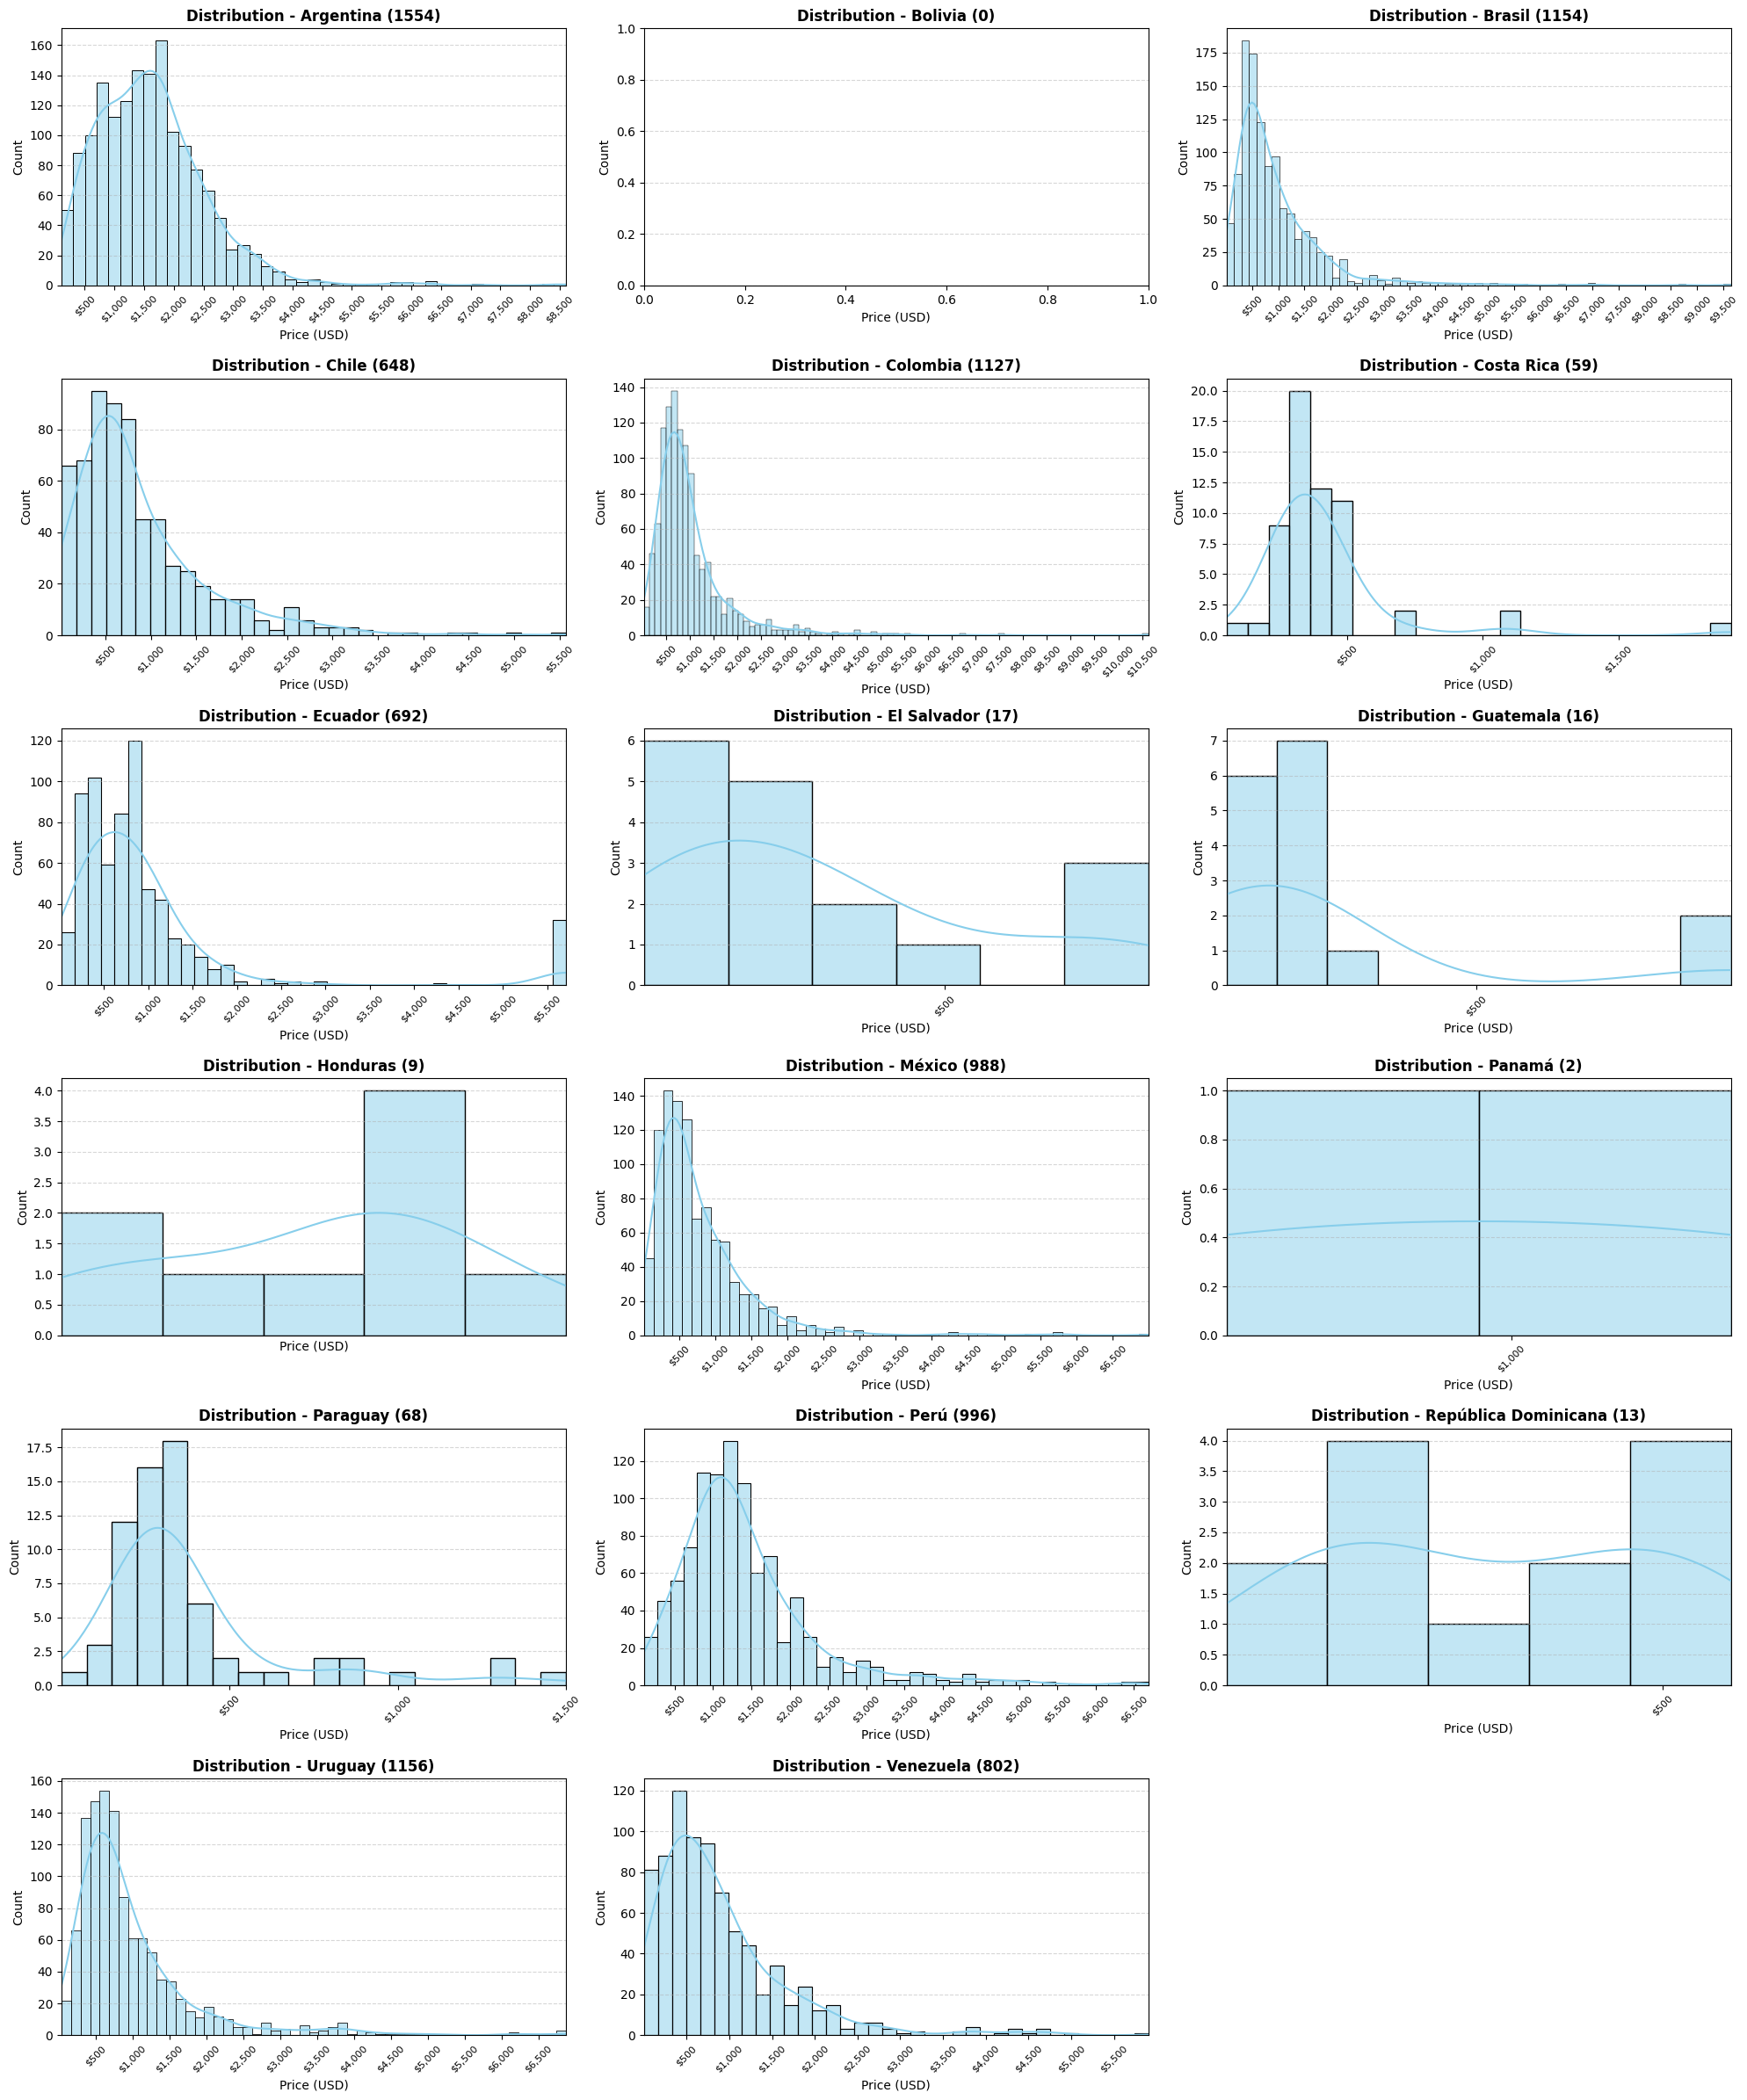

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.ticker as ticker

# Assuming your dictionary is named `country_dfs`
# country_dfs = {"USA": df1, "Canada": df2, ...}
country_names = list(filtered_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_dataframes[country].copy()
    
    # Check if column exists to avoid errors
    if 'to_dollar' in df.columns:
        min_val = df['to_dollar'].min()
        max_val = df['to_dollar'].max()

        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            binrange=(min_val, max_val),
            edgecolor='black'
        )

        ax.set_xlim(left=min_val, right=max_val)

        # --- NEW TICK ADJUSTMENTS ---
        # 1. Force a tick mark exactly every 200 units on the x-axis
        ax.xaxis.set_major_locator(ticker.MultipleLocator(500))
        
        # 2. (Optional) Format numbers cleanly with commas and rotate to prevent crowding
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x):,}'))
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Customize individual subplot
    ax.set_title(f'Distribution - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
# plt.savefig('countries_prices_grid.png', dpi=300)

## RAM

Argentina ram
16     644
8      418
32     142
4      136
24      98
40      56
64      33
12      16
20       4
6        2
128      2
36       1
48       1
10       1
Name: count, dtype: int64
NO Hay elementos que plotear
Brasil ram
8      474
16     399
4      142
32      58
24      22
2       13
12      12
64      10
48       5
6        5
3        3
40       3
128      2
1        2
36       2
5        1
512      1
Name: count, dtype: int64
Chile ram
16     252
8      194
4       75
32      51
2       25
24      19
12       9
3        9
1        6
128      2
20       2
36       1
64       1
512      1
48       1
Name: count, dtype: int64
Colombia ram
16     452
8      318
32     110
24      95
4       55
12      33
40      30
64      11
48       5
20       5
128      4
1        3
43       1
36       1
96       1
3        1
10       1
5        1
Name: count, dtype: int64
Costa Rica ram
16    27
32    13
8      9
4      5
64     4
12     1
Name: count, dtype: int64
Ecuador ram
16     2

<Figure size 640x480 with 0 Axes>

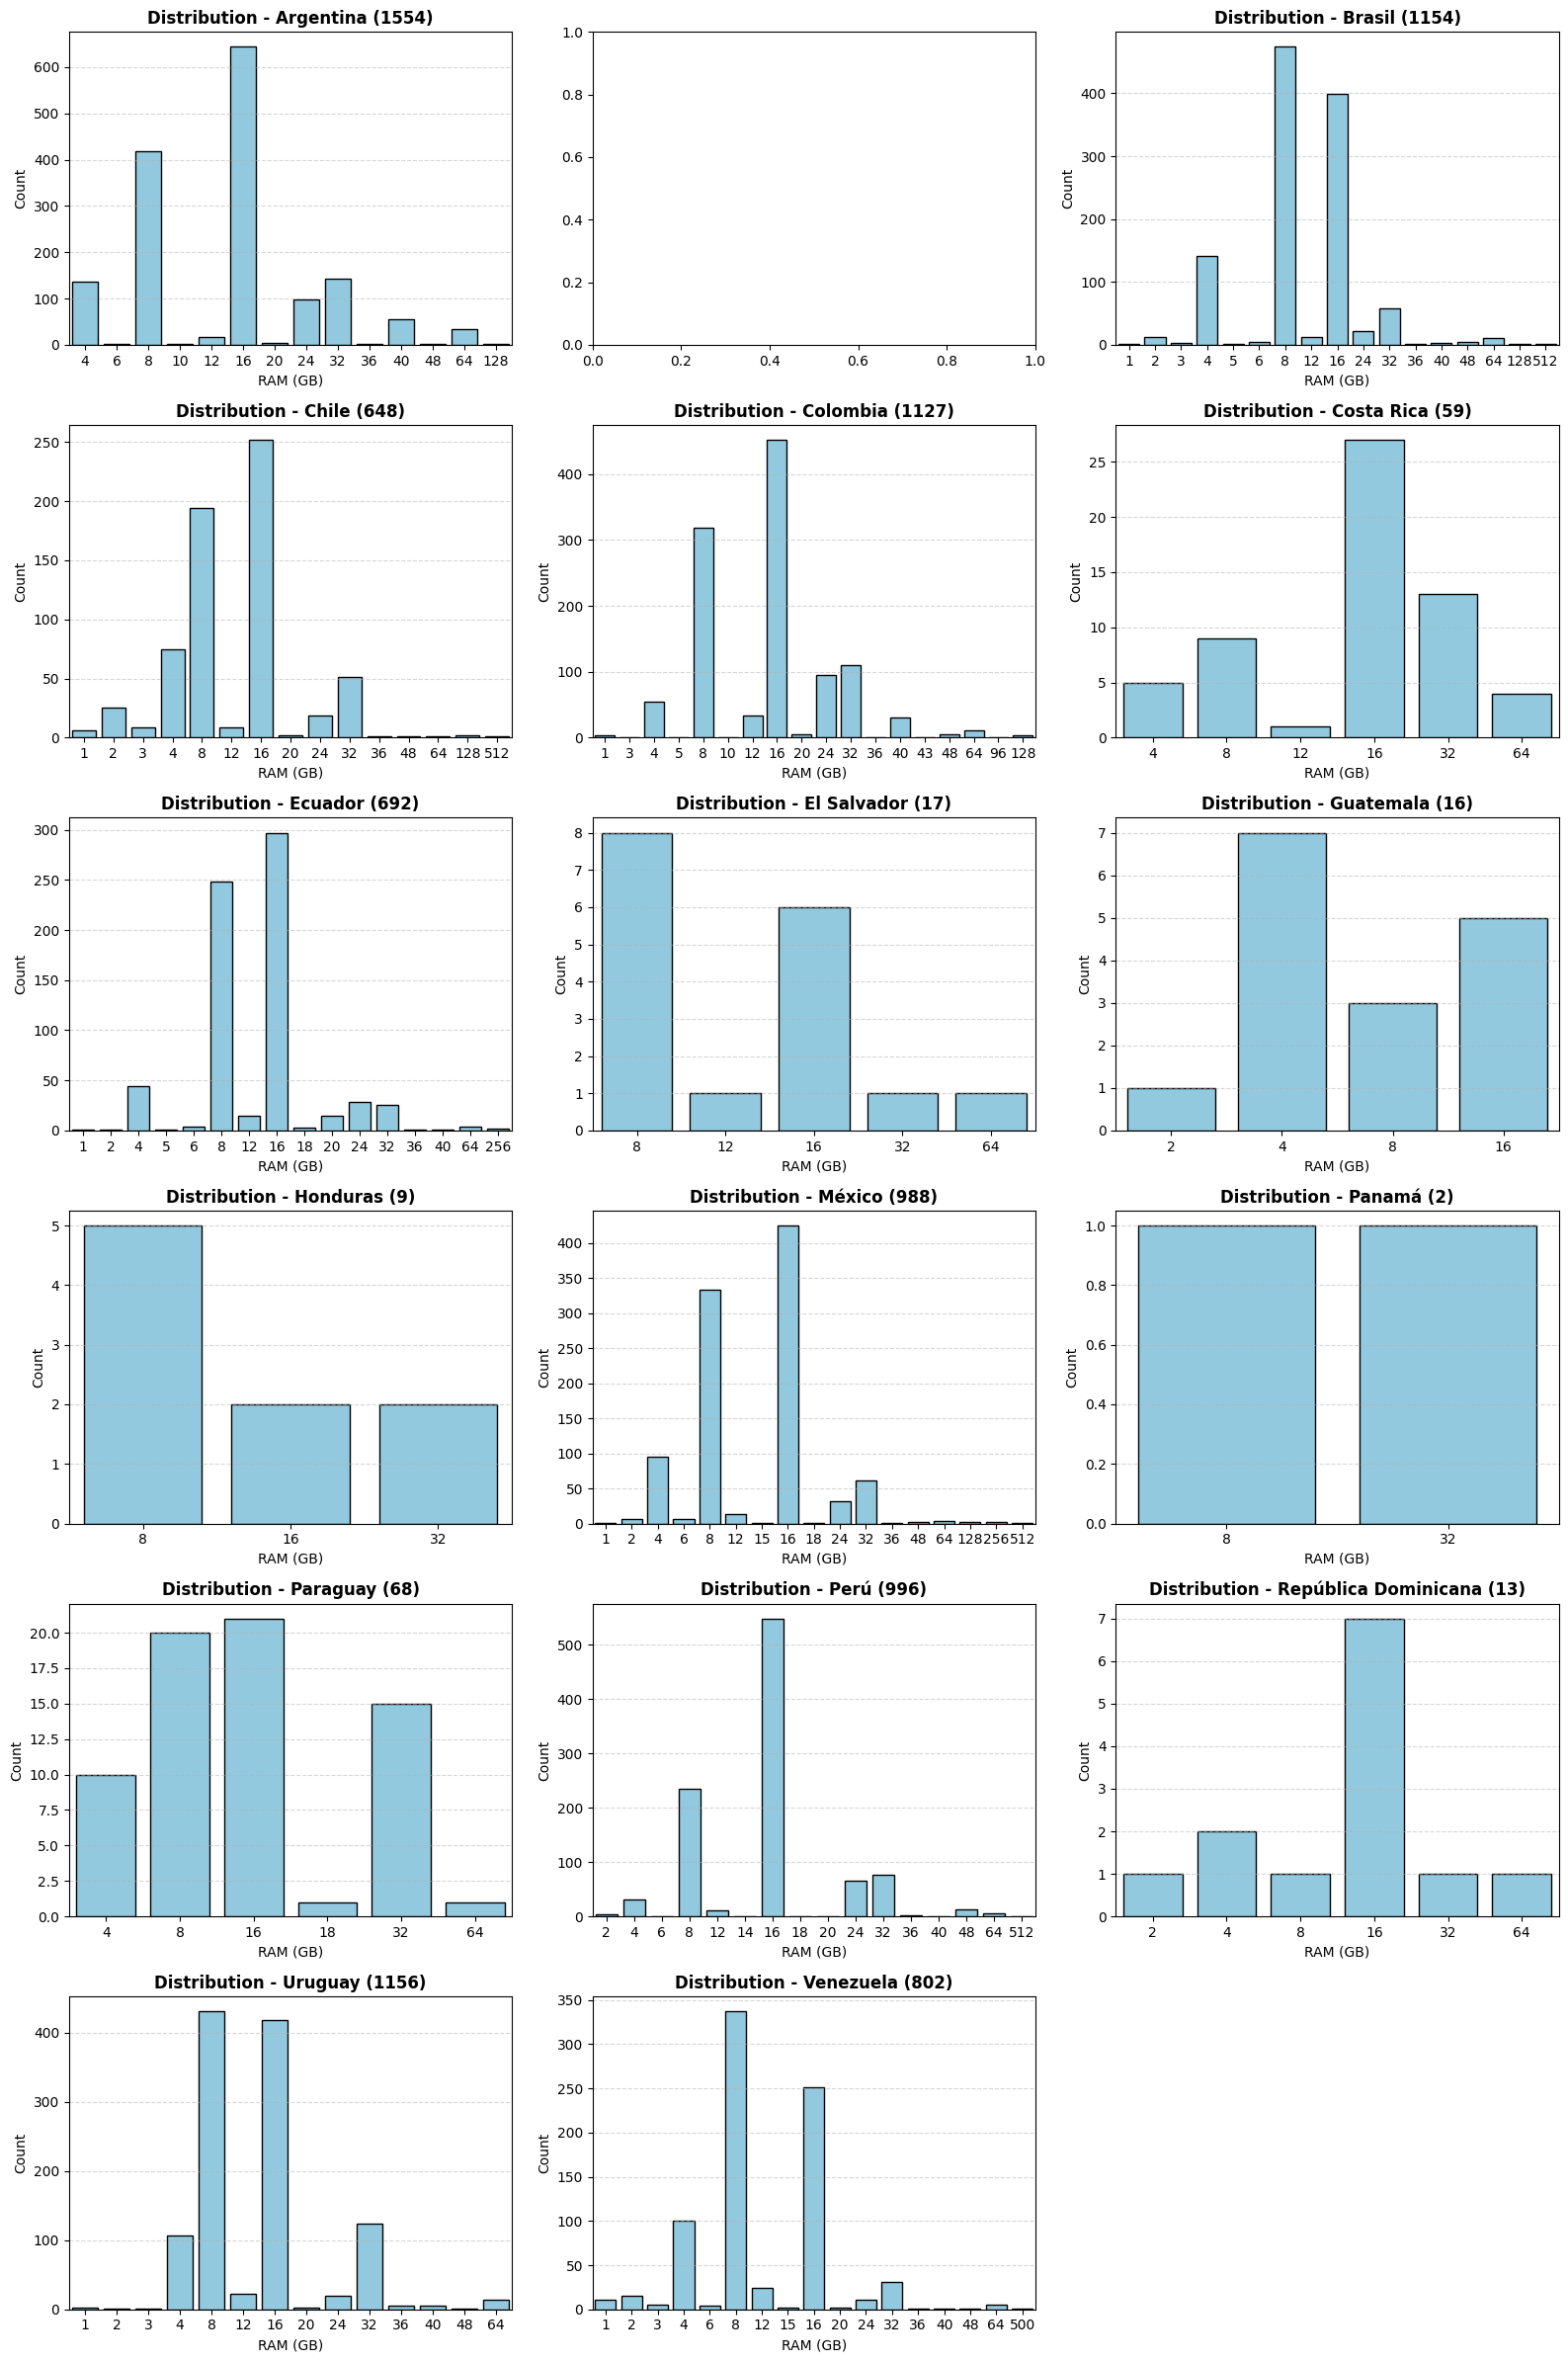

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import ast
import re

# Ensure all necessary libraries are imported
# Assuming your dictionary is named `filtered_dataframes`
country_names = list(filtered_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_dataframes[country].copy()
    
    # Safe evaluation of the stringified dictionary
    try:
        df["especificaciones"] = df["especificaciones"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    except:
        print("NO Hay elementos que plotear")
        continue
    # Extract RAM dynamically (switched regex to '\d+' to match numbers reliably)
    if country == "Brasil":
        df["ram"] = df["especificaciones"].apply(lambda x: int(re.findall(r"\d+", str(x.get("Capacidade total do módulo de memória RAM", "0")))[0]))
    else:
        df["ram"] = df["especificaciones"].apply(lambda x: int(re.findall(r"\d+", str(x.get("Capacidad total del módulo de memoria RAM", "0")))[0]))

    print(country, df["ram"].value_counts())
    
    # Plot using a categorical bar plot (countplot) instead of a histogram
    if 'ram' in df.columns and not df.empty:
        sns.countplot(
            data=df, 
            x='ram', 
            ax=ax, 
            color='skyblue', 
            edgecolor='black',
            order=sorted(df['ram'].unique())  # Keeps the RAM configurations sorted sequentially (e.g., 4, 8, 16...)
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('RAM (GB)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
plt.savefig('countries_ram_grid.png', dpi=300)

## almacenamiento SSD

NO HAY ELEMENTOS QUE PLOTEAR


<Figure size 640x480 with 0 Axes>

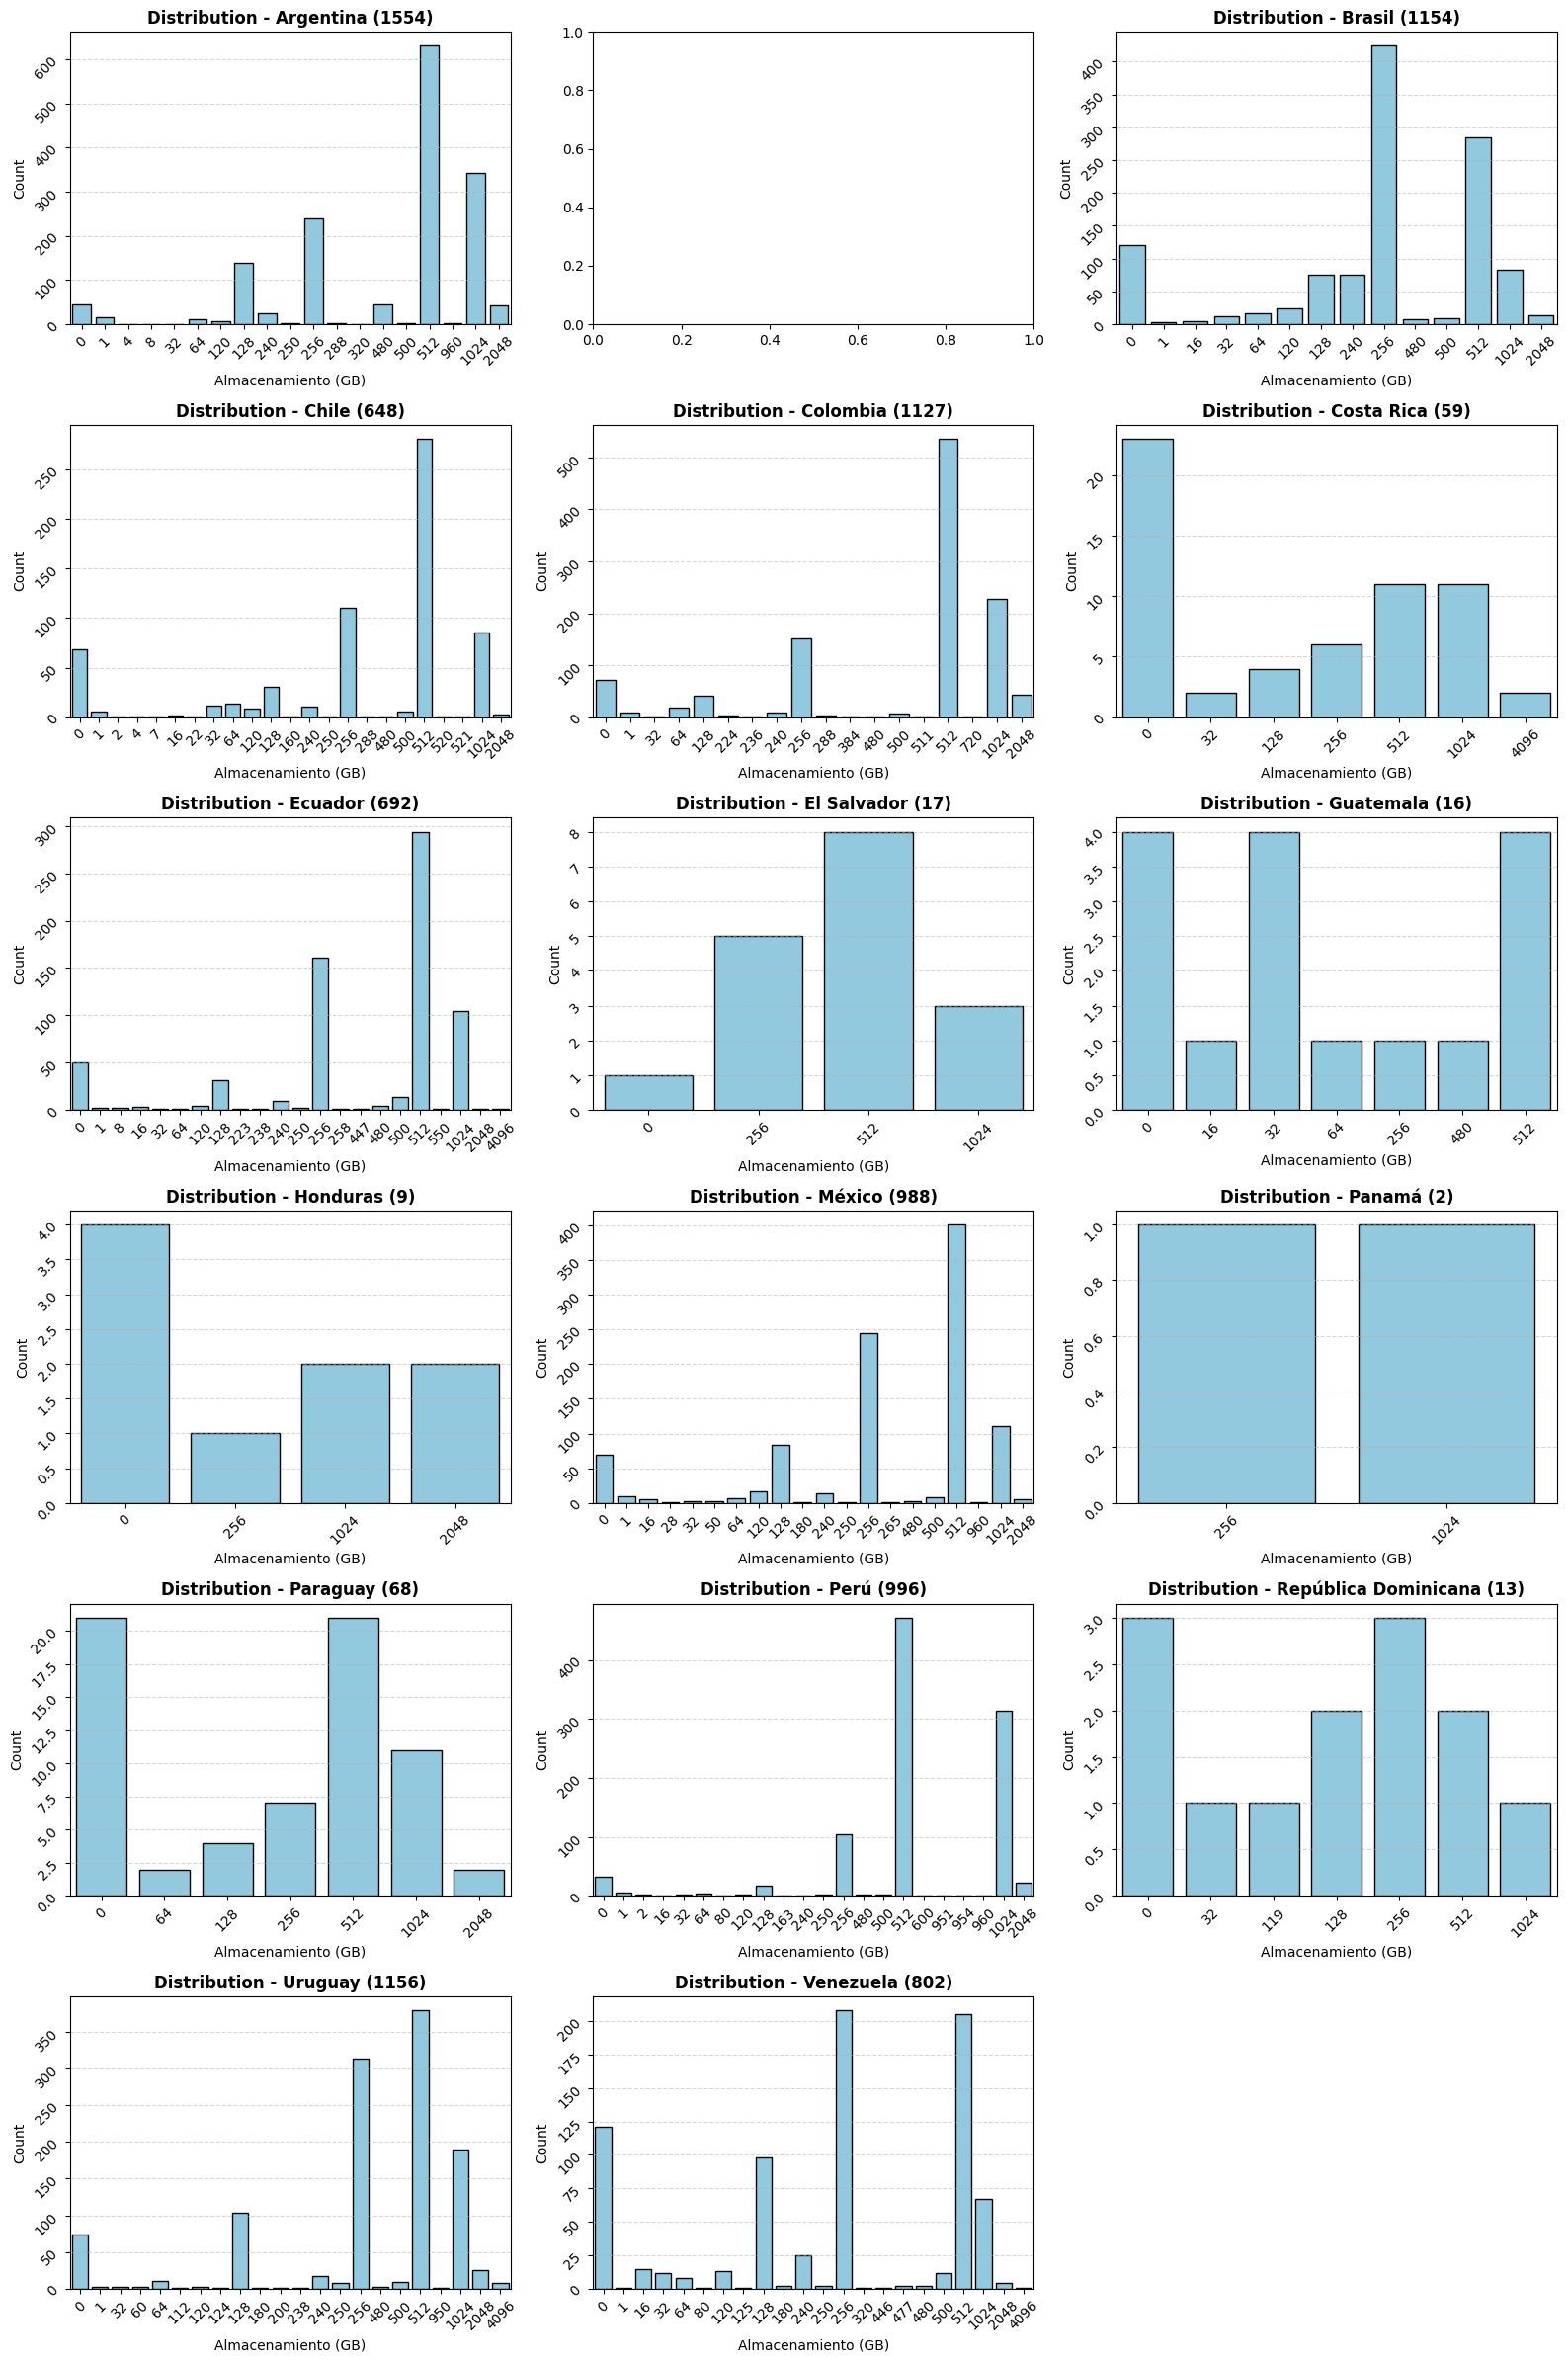

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import ast
import re

# Ensure all necessary libraries are imported
# Assuming your dictionary is named `filtered_dataframes`
country_names = list(filtered_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

def gb_or_tb(s):
    disk_size = int(re.findall(r"\d+", str(s))[0])
    if "TB" in s:
        if len(str(disk_size)) == 1:
            return disk_size*1024
    return disk_size
 
# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_dataframes[country].copy()
    
    # Safe evaluation of the stringified dictionary
    try:
        df["especificaciones"] = df["especificaciones"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    except:
        print("NO HAY ELEMENTOS QUE PLOTEAR")
        continue
    
    # Extract RAM dynamically (switched regex to '\d+' to match numbers reliably)
    if country == "Brasil":
        df["almacenamiento"] = df["especificaciones"].apply(lambda x: gb_or_tb(str(x.get("Capacidade de disco SSD", "0"))))
    else:
        df["almacenamiento"] = df["especificaciones"].apply(lambda x: gb_or_tb(str(x.get("Capacidad de disco SSD", "0"))))
    
    # Plot using a categorical bar plot (countplot) instead of a histogram
    if 'almacenamiento' in df.columns and not df.empty:
        sns.countplot(
            data=df, 
            x='almacenamiento', 
            ax=ax, 
            color='skyblue', 
            edgecolor='black',
            order=sorted(df['almacenamiento'].unique())  # Keeps the RAM configurations sorted sequentially (e.g., 4, 8, 16...)
        )
    
    ax.tick_params(rotation=45)
    # Customize individual subplot
    ax.set_title(f'Distribution - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Almacenamiento (GB)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
plt.savefig('countries_ram_grid.png', dpi=300)

# HDD

Argentina almacenamiento
0       1432
512       41
1024      23
256       16
128       14
64        10
320        5
32         3
500        3
120        2
288        2
2048       1
24         1
265        1
Name: count, dtype: int64
NO HAY ELEMENTOS QUE PLOTEAR
Brasil almacenamiento
0       962
1024     50
512      32
500      30
256      20
2048     10
64        8
240       8
320       5
16        5
1         4
160       4
128       4
250       2
32        2
480       2
4096      2
8192      1
300       1
120       1
24        1
Name: count, dtype: int64
Chile almacenamiento
0       520
500      34
1024     22
512      21
320      15
256      12
128       4
2048      3
32        2
2         2
250       2
64        2
120       2
16        1
192       1
160       1
750       1
4         1
480       1
7         1
Name: count, dtype: int64
Colombia almacenamiento
0       974
512      54
1024     30
256      24
128      16
64        5
500       4
288       3
16        2
2048      2
224    

<Figure size 640x480 with 0 Axes>

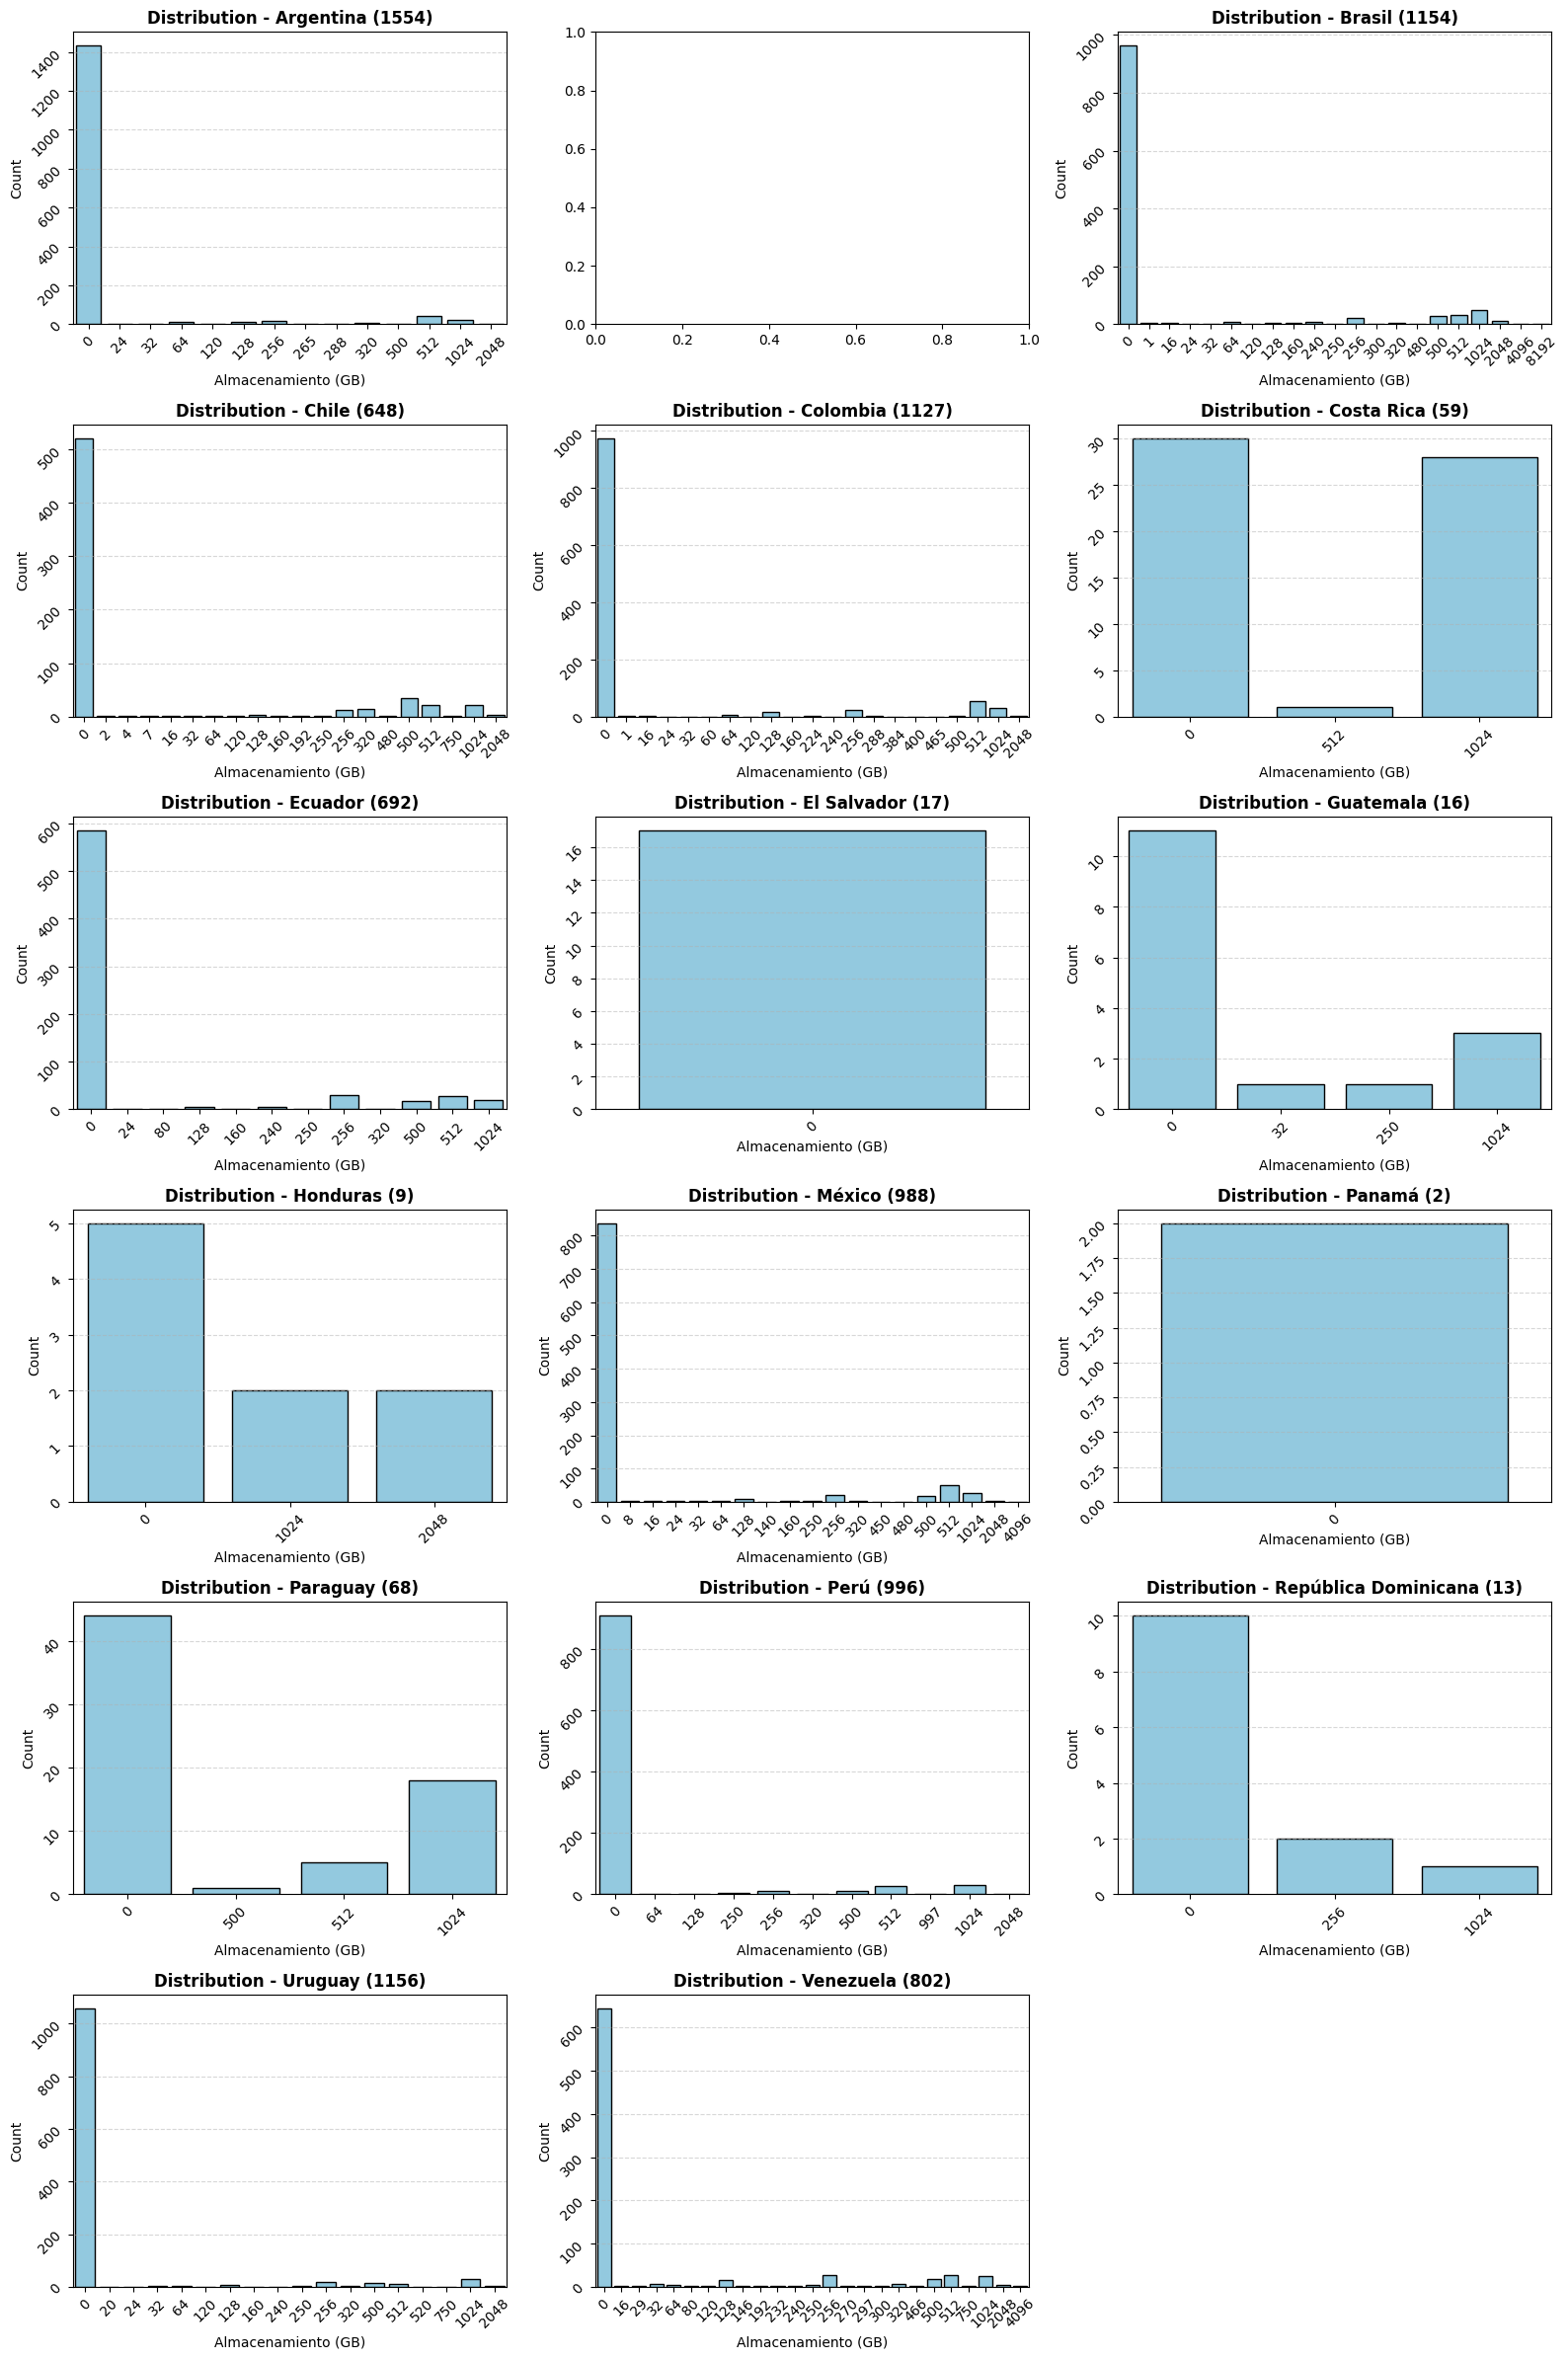

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import ast
import re

# Ensure all necessary libraries are imported
# Assuming your dictionary is named `filtered_dataframes`
country_names = list(filtered_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

def gb_or_tb(s):
    disk_size = int(re.findall(r"\d+", str(s))[0])
    if "TB" in s:
        if len(str(disk_size)) == 1:
            return disk_size*1024
    return disk_size

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_dataframes[country].copy()
    
    # Safe evaluation of the stringified dictionary
    try:
        df["especificaciones"] = df["especificaciones"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    except:
        print("NO HAY ELEMENTOS QUE PLOTEAR")
        continue
    
    # Extract disk size dynamically (switched regex to '\d+' to match numbers reliably)
    if country == "Brasil":
        df["almacenamiento"] = df["especificaciones"].apply(lambda x: gb_or_tb(x.get("Capacidade de disco HD", "0")))
    elif country in ["Colombia", "México", "Venezuela"]:
        df["almacenamiento"] = df["especificaciones"].apply(lambda x: gb_or_tb(x.get("Capacidad del disco duro", "0")))
    else:
        df["almacenamiento"] = df["especificaciones"].apply(lambda x: gb_or_tb(x.get("Capacidad del disco rígido", "0")))

    print(country, df["almacenamiento"].value_counts())
    
    # Plot using a categorical bar plot (countplot) instead of a histogram
    if 'almacenamiento' in df.columns and not df.empty:
        sns.countplot(
            data=df, 
            x='almacenamiento', 
            ax=ax, 
            color='skyblue', 
            edgecolor='black',
            order=sorted(df['almacenamiento'].unique())  # Keeps the RAM configurations sorted sequentially (e.g., 4, 8, 16...)
        )
    
    ax.tick_params(rotation=45)

    # Customize individual subplot
    ax.set_title(f'Distribution - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Almacenamiento (GB)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
plt.savefig('countries_ram_grid.png', dpi=300)

# specs filters

In [64]:
def check_specs_storage(s):
    i = re.findall(r"\d*", s)[0]
    
    if "GB" not in s and "TB" not in s:
        return False
    if "TB" in s:
        i = i*1024
    elif int(i) < 128 or int(i) > 512:
        return False
    else:
        return True
    
def check_specs_ram(s):
    i = re.findall(r"\d*", s)[0]
    
    if "GB" not in s:
        return False
    elif int(i) < 4 or int(i) > 16:
    # elif int(i) != 4:
        return False
    else:
        return True

In [65]:
filtered_specs_dataframes = {}

for k, v in filtered_dataframes.items(): 
    filtered = []
    for i, a in v.iterrows():
        specs = ast.literal_eval(a["especificaciones"])
        
        if k == "Brasil":
            # storage = specs.get("Memória interna", "")
            ram = specs.get("Capacidade total do módulo de memória RAM", "")
        else:
            # storage = specs.get("Memoria interna", "")
            ram = specs.get("Capacidad total del módulo de memoria RAM", "")

        if check_specs_ram(ram):
            filtered.append(a)

    filtered_specs_dataframes[k] = pd.DataFrame(filtered)

<Figure size 640x480 with 0 Axes>

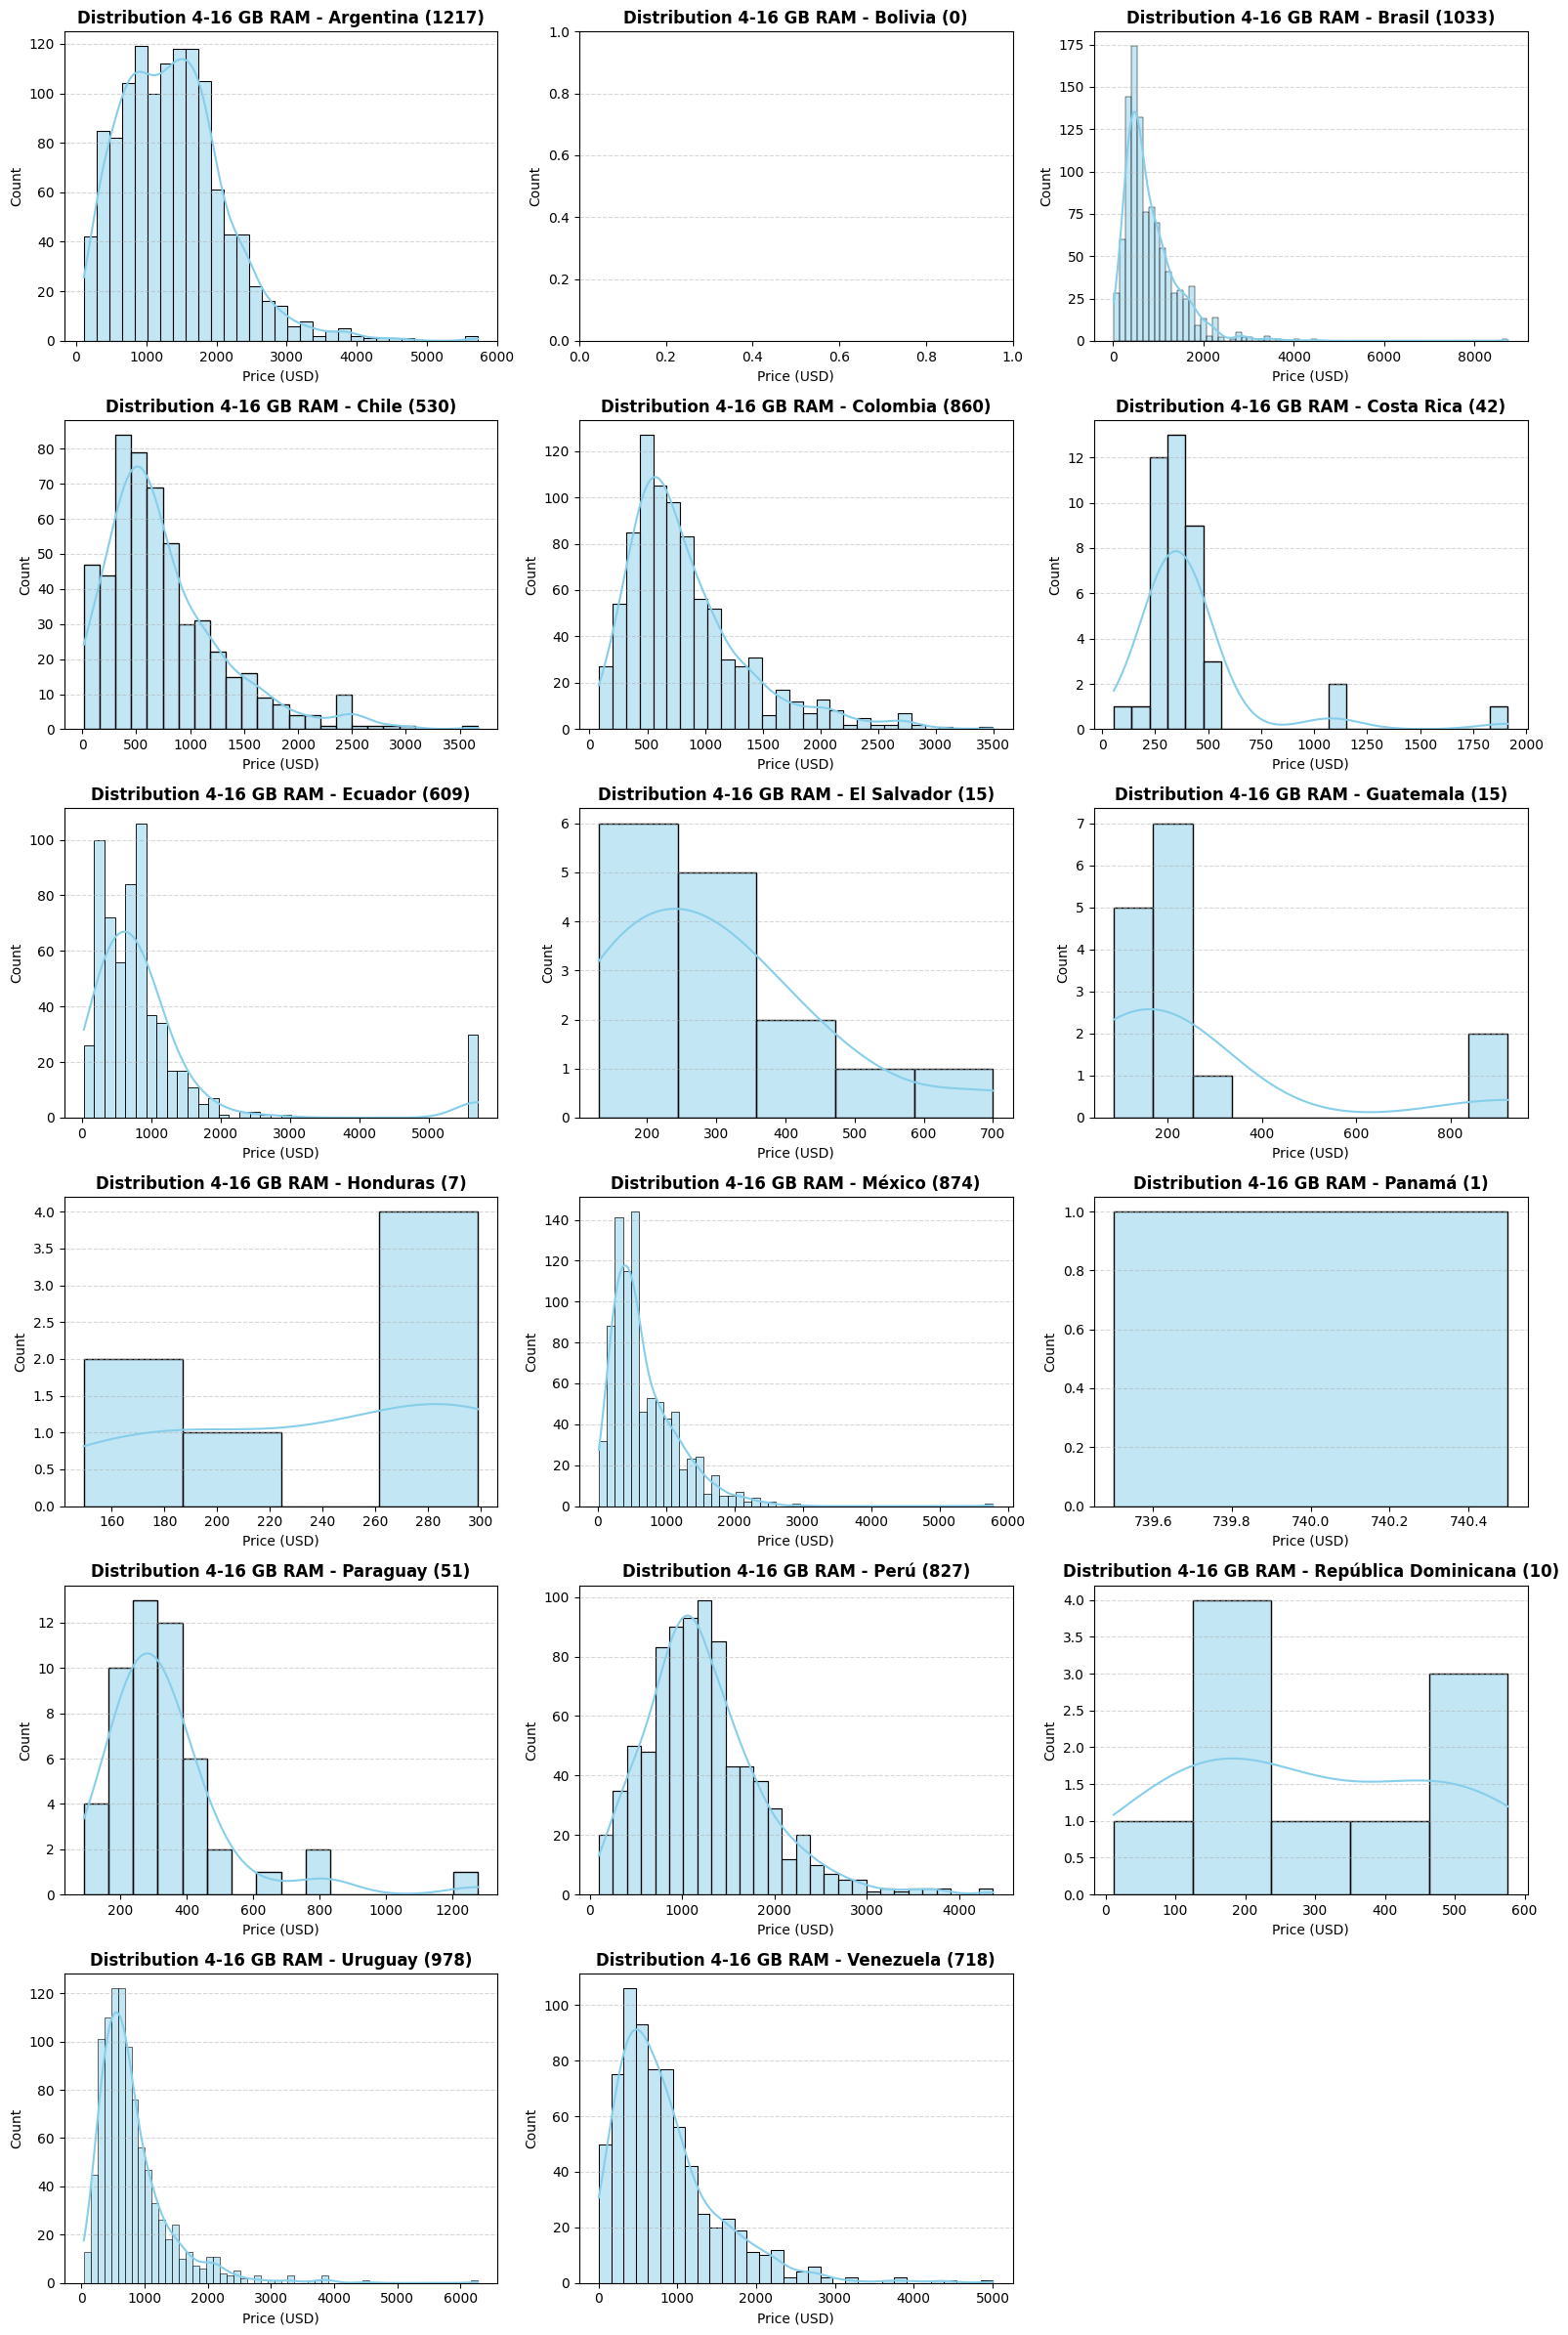

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assuming your dictionary is named `country_dfs`
# country_dfs = {"USA": df1, "Canada": df2, ...}
country_names = list(filtered_specs_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_specs_dataframes[country]
    
    # Check if column exists to avoid errors
    if 'to_dollar' in df.columns:
        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            edgecolor='black'
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution 4-16 GB RAM - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
# plt.savefig('countries_prices_grid.png', dpi=300)

In [67]:
def correct_gb_tb(s):
    disk_size = int(re.findall(r"\d+", str(s))[0])
    if "TB" in s:
        if len(str(disk_size)) == 1:
            return disk_size*1024
    return disk_size

def check_specs_storage_both(sdd_string, hdd_string):
    if ("GB" not in sdd_string and "TB" not in sdd_string) and ("GB" not in hdd_string and "TB" not in hdd_string):
        return False

    # sdd = re.findall(r"\d*", str(sdd_string))[0]
    # hdd = re.findall(r"\d*", str(hdd_string))[0]

    sdd = correct_gb_tb(sdd_string)
    hdd = correct_gb_tb(hdd_string)

    # if "TB" in sdd:
    #     sdd = int(sdd)*1024
    # if "TB" in hdd:
    #     hdd = int(hdd)*1024
    
    if (int(sdd) < 128 or int(sdd) > 512) and (int(hdd) < 128 or int(hdd) > 512):
        return False
    else:
        return True

In [68]:
filtered_specs_space_dataframes = {}

for k, v in filtered_dataframes.items(): 
    filtered = []
    for i, a in v.iterrows():
        specs = ast.literal_eval(a["especificaciones"])
        
        if k == "Brasil":
            hdd = specs.get("Capacidade de disco HD", "0")
            sdd = specs.get("Capacidade de disco SSD", "0")
        elif country in ["Colombia", "México", "Venezuela"]:
            hdd = specs.get("Capacidade del disco duro", "0")
            sdd = specs.get("Capacidad de disco SSD", "0")
        else:
            sdd = specs.get("Capacidad de disco SSD", "0")
            hdd = specs.get("Capacidad del disco rígido", "0")

        if check_specs_storage_both(sdd, hdd):
            filtered.append(a)

    filtered_specs_space_dataframes[k] = pd.DataFrame(filtered)

<Figure size 640x480 with 0 Axes>

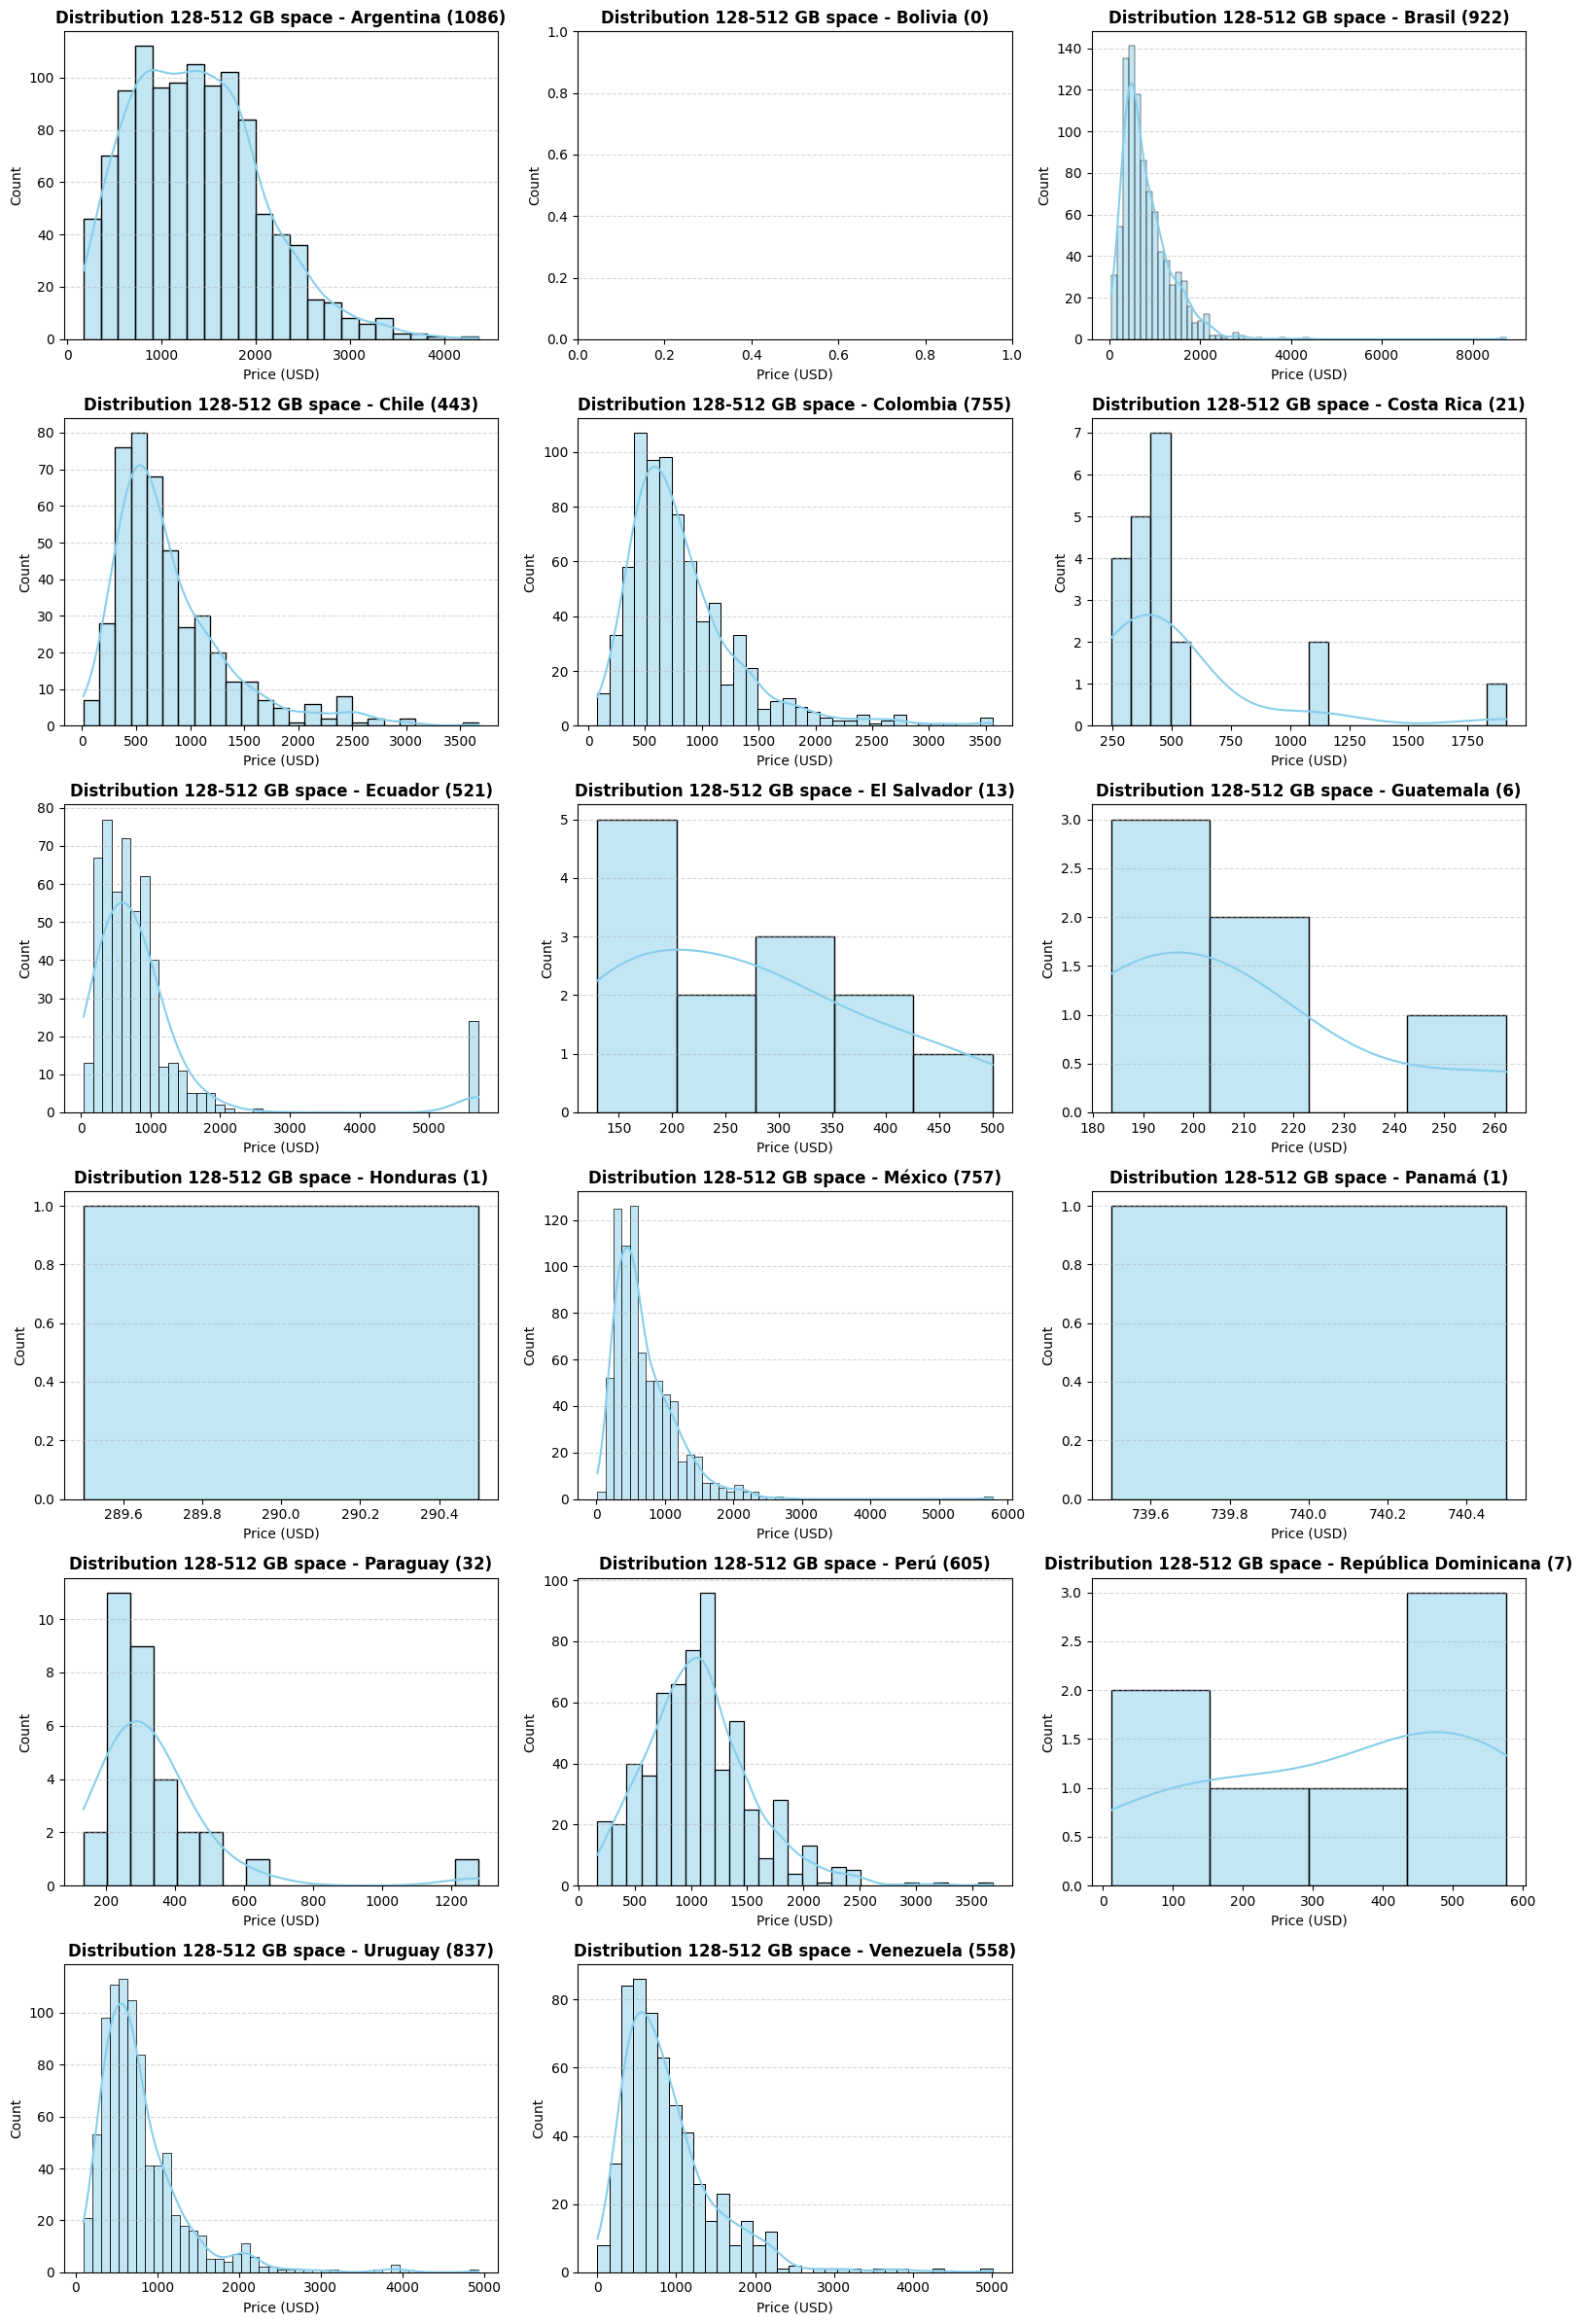

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assuming your dictionary is named `country_dfs`
# country_dfs = {"USA": df1, "Canada": df2, ...}
country_names = list(filtered_specs_space_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_specs_space_dataframes[country]
    
    # Check if column exists to avoid errors
    if 'to_dollar' in df.columns:
        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            edgecolor='black'
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution 128-512 GB space - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
# plt.savefig('countries_prices_grid.png', dpi=300)

# both filters

In [70]:
filtered_specs_space_ram_dataframes = {}

for k, v in filtered_dataframes.items(): 
    filtered = []
    for i, a in v.iterrows():
        specs = ast.literal_eval(a["especificaciones"])
        
        if k == "Brasil":
            ram = specs.get("Capacidade total do módulo de memória RAM", "0")
            hdd = specs.get("Capacidade de disco HD", "0")
            sdd = specs.get("Capacidade de disco SSD", "0")
        elif country in ["Colombia", "México", "Venezuela"]:
            ram = specs.get("Capacidad total del módulo de memoria RAM", "0")
            hdd = specs.get("Capacidade del disco duro", "0")
            sdd = specs.get("Capacidad de disco SSD", "0")
        else:
            ram = specs.get("Capacidad total del módulo de memoria RAM", "0")
            sdd = specs.get("Capacidad de disco SSD", "0")
            hdd = specs.get("Capacidad del disco rígido", "0")

        if all([check_specs_ram(ram), check_specs_storage_both(sdd, hdd)]):
            filtered.append(a)

    filtered_specs_space_ram_dataframes[k] = pd.DataFrame(filtered)

<Figure size 640x480 with 0 Axes>

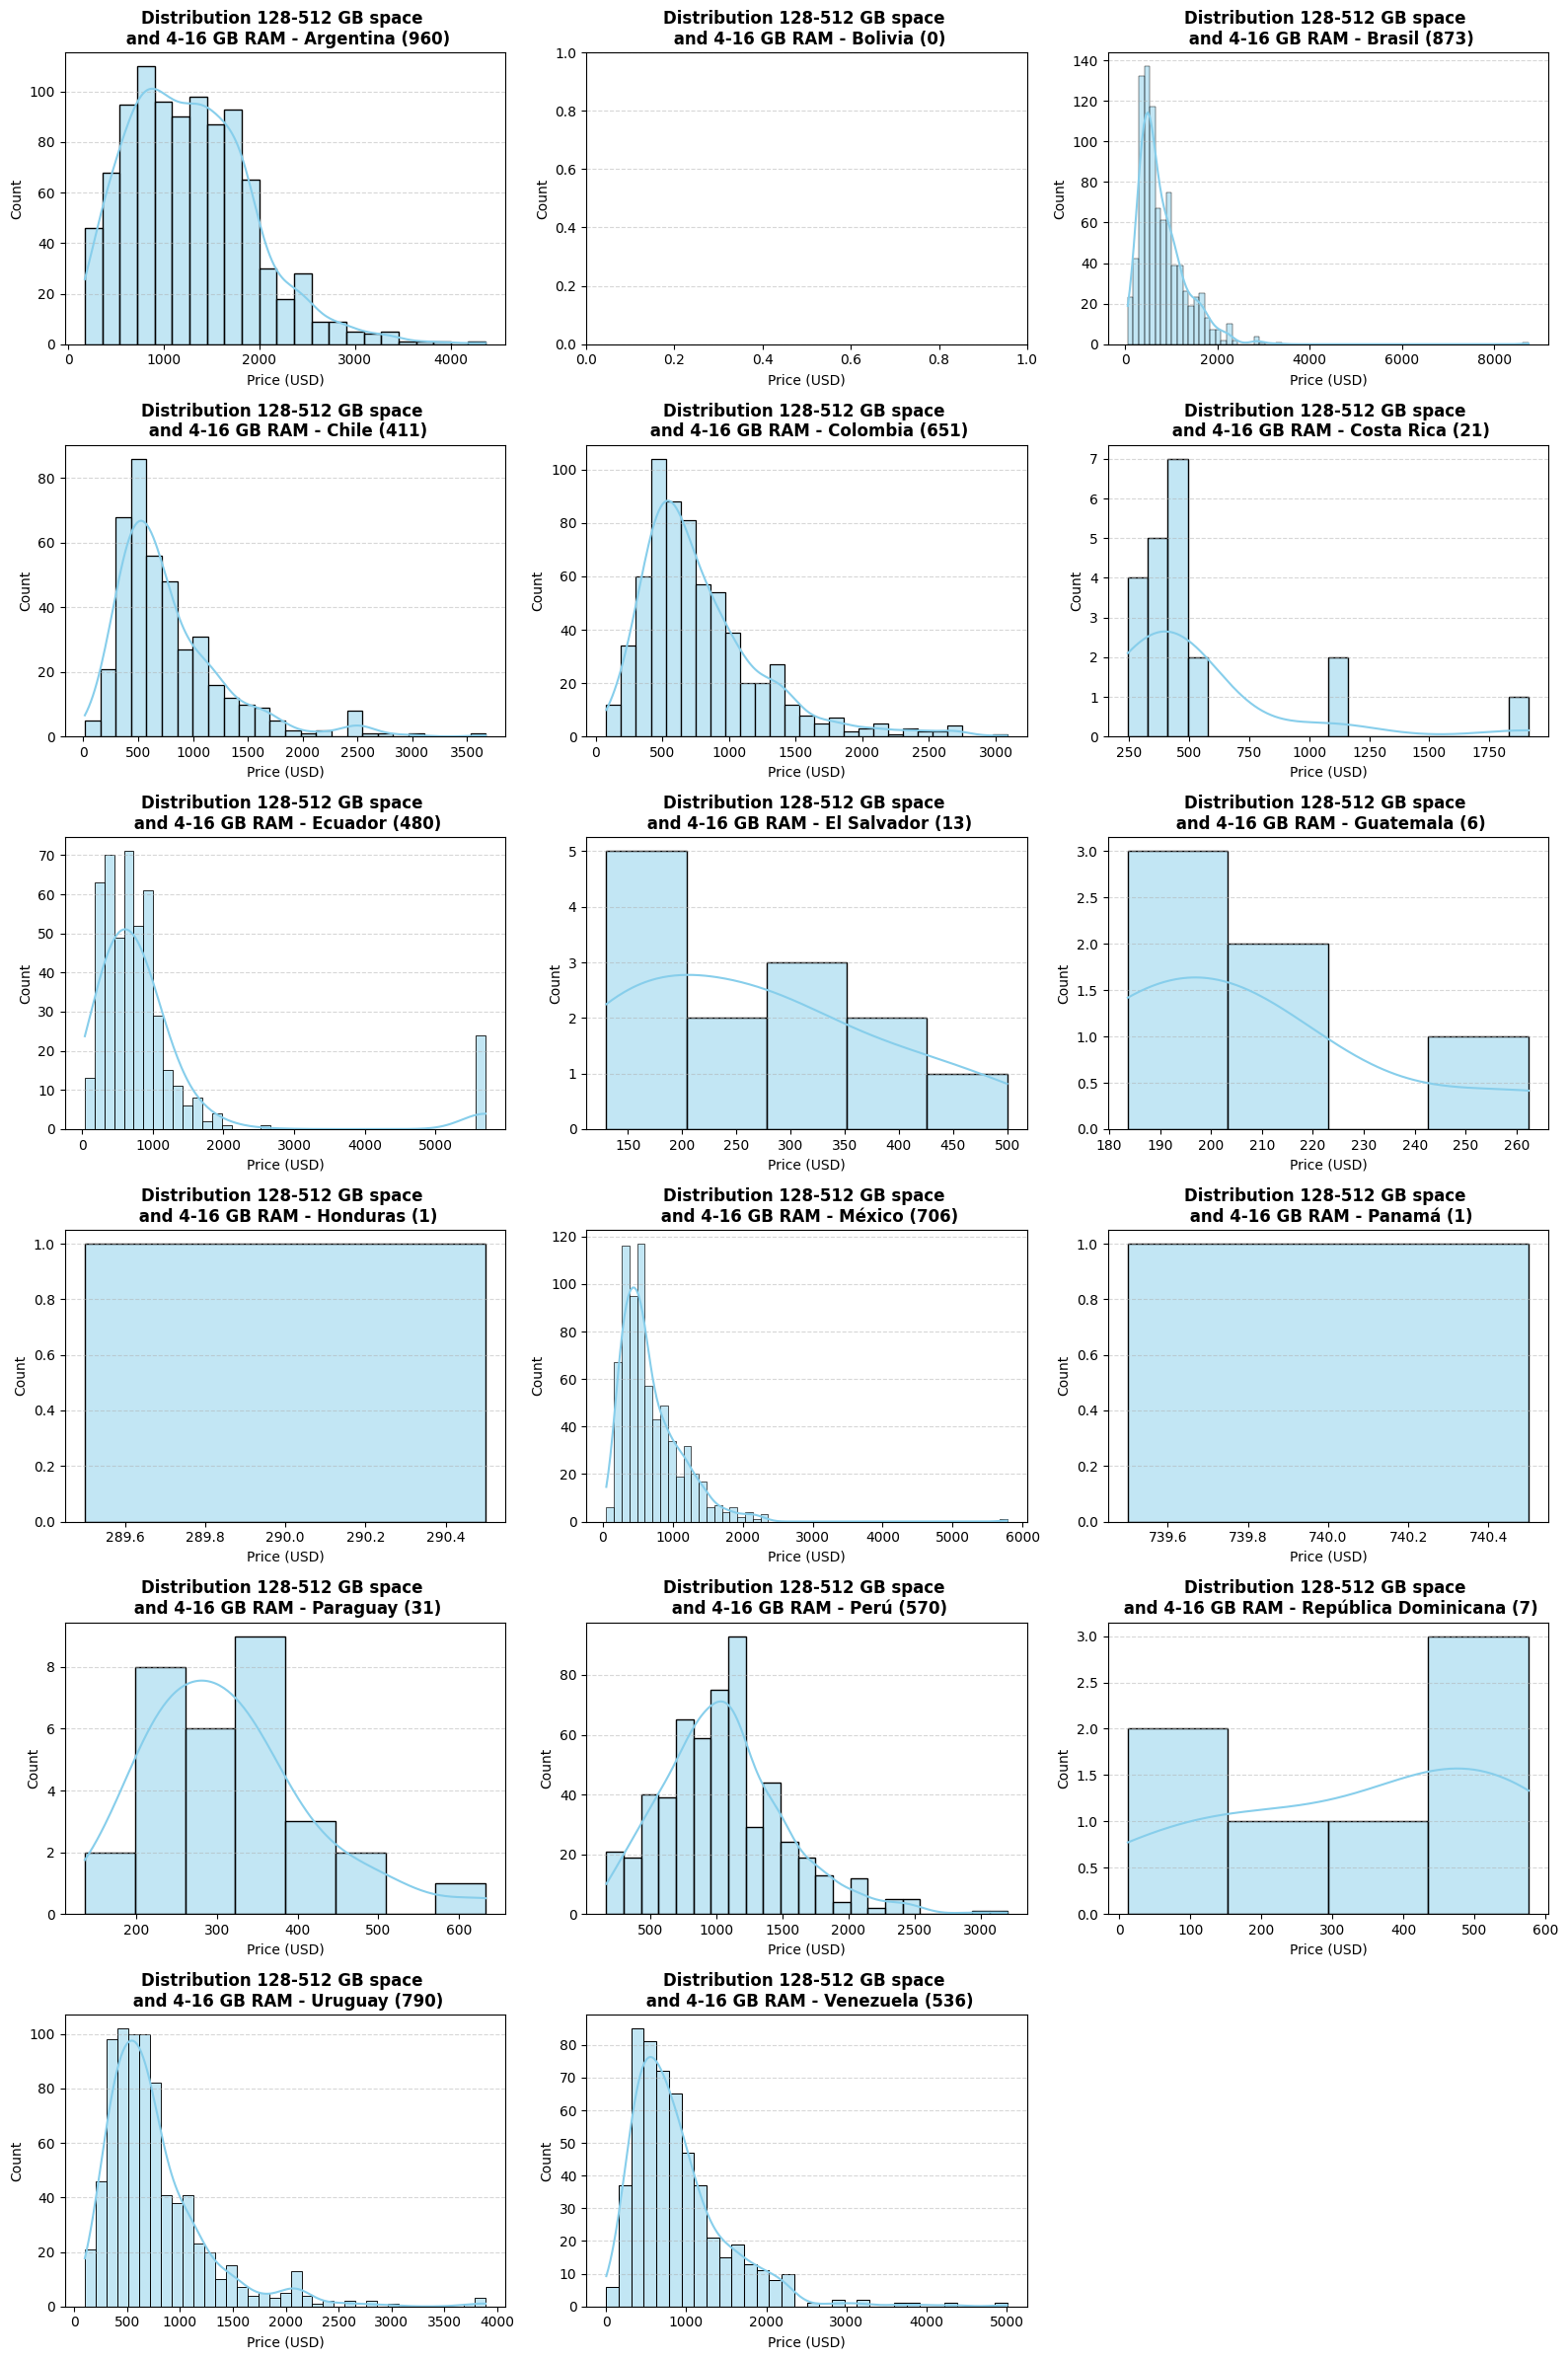

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assuming your dictionary is named `country_dfs`
# country_dfs = {"USA": df1, "Canada": df2, ...}
country_names = list(filtered_specs_space_ram_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_specs_space_ram_dataframes[country]
    
    # Check if column exists to avoid errors
    if 'to_dollar' in df.columns:
        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            edgecolor='black'
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution 128-512 GB space \n and 4-16 GB RAM - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
# plt.savefig('countries_prices_grid.png', dpi=300)

# skewness y deciles

<Figure size 640x480 with 0 Axes>

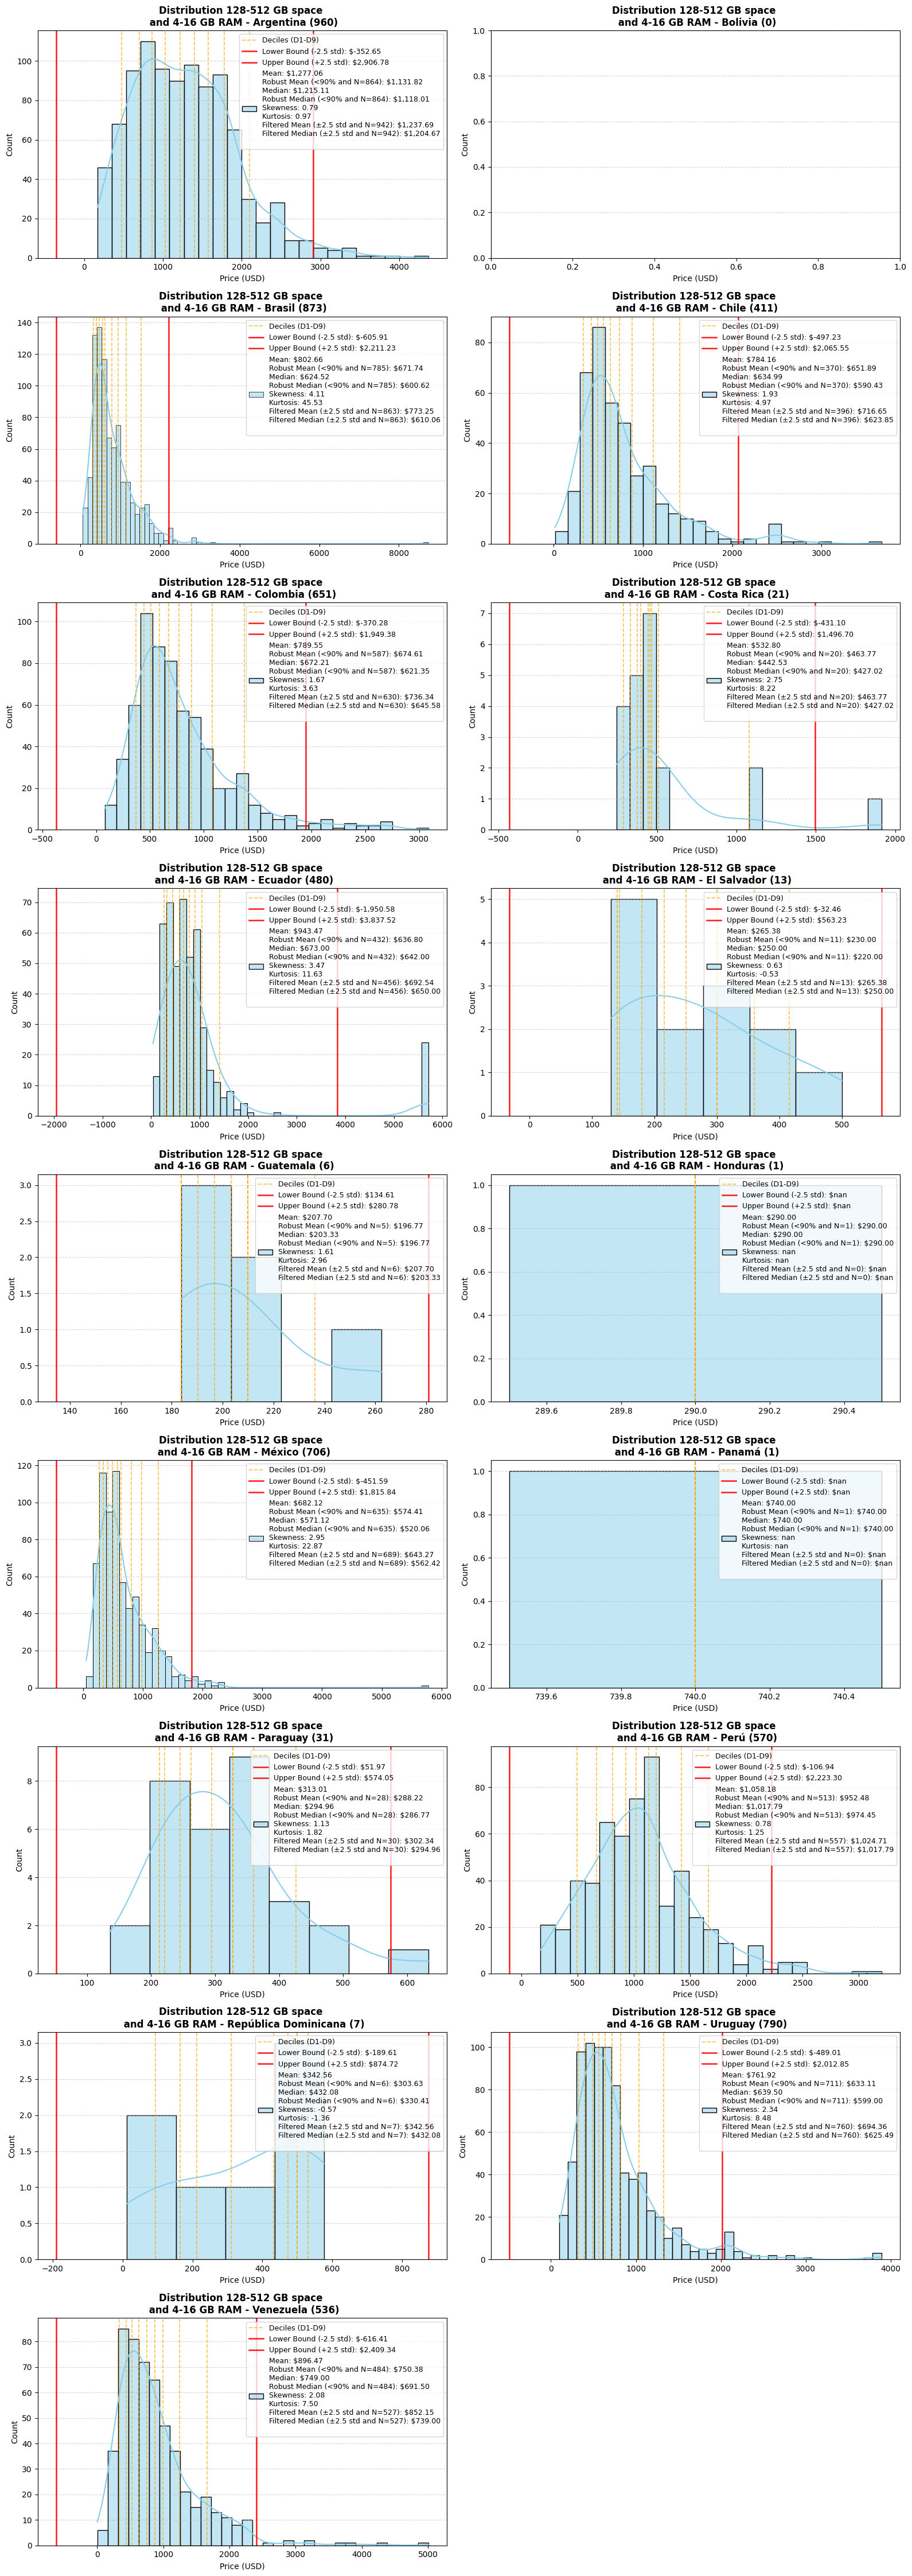

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np  # Added for generating the decile percentiles

# Assuming your dictionary is named `country_dfs`
# country_dfs = {"USA": df1, "Canada": df2, ...}
country_names = list(filtered_specs_space_ram_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 2
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_specs_space_ram_dataframes[country]
    
    # Check if column exists to avoid errors
    if 'to_dollar' in df.columns:
        mean_val = df['to_dollar'].mean()
        median_val = df['to_dollar'].median()
        
        skew_val = df['to_dollar'].skew()
        kurt_val = df['to_dollar'].kurtosis()  # Measures the "tailedness" / outlier weight

        # 2. NEW: Calculate the 90th percentile and the Robust Trimmed Mean
        q_90 = df['to_dollar'].quantile(0.9)
        q_90_n = len(df[df['to_dollar'] <= q_90])
        robust_mean_val = df[df['to_dollar'] <= q_90]['to_dollar'].mean()
        robust_median_val = df[df['to_dollar'] <= q_90]['to_dollar'].median()
        
        std_val = df['to_dollar'].std()
        std_ponderator = 2.5
        two_point_five_std = std_ponderator * std_val

        # 3. Filter data within +/- 1 Std Dev from the original mean
        lower_bound = mean_val - two_point_five_std
        upper_bound = mean_val + two_point_five_std
        filtered_df = df[(df['to_dollar'] >= lower_bound) & (df['to_dollar'] <= upper_bound)]

        filtered_n = len(filtered_df)

        # Calculate robust central tendencies on this filtered subset
        filtered_mean = filtered_df['to_dollar'].mean()
        filtered_median = filtered_df['to_dollar'].median()


        # 2. Compile metrics into a cleanly stacked multi-line label
        metric_label = (
            f'Mean: ${mean_val:,.2f}\n'
            f'Robust Mean (<90% and N={q_90_n}): ${robust_mean_val:,.2f}\n'
            f'Median: ${median_val:,.2f}\n'
            f'Robust Median (<90% and N={q_90_n}): ${robust_median_val:,.2f}\n'
            f'Skewness: {skew_val:.2f}\n'
            f'Kurtosis: {kurt_val:.2f}\n'
            f'Filtered Mean (±{std_ponderator} std and N={filtered_n}): ${filtered_mean:,.2f}\n'
            f'Filtered Median (±{std_ponderator} std and N={filtered_n}): ${filtered_median:,.2f}\n'
        )

        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            edgecolor='black',
            label=metric_label        
            )

        # 2. Calculate the 9 deciles (0.1, 0.2, ..., 0.9)
        deciles = df['to_dollar'].quantile(np.arange(0.1, 1.0, 0.1))
        
        # 3. Plot vertical lines for deciles
        for idx, decile in enumerate(deciles):
            # Only label the first line so "Deciles" shows up exactly once in the legend
            line_label = 'Deciles (D1-D9)' if idx == 0 else ""
            ax.axvline(
                x=decile, 
                color='orange', 
                linestyle='--', 
                linewidth=1.2, 
                alpha=0.7,
                label=line_label
            )

        # 8. NEW: Add two solid red vertical lines for the +/- 2.5 std boundaries
        ax.axvline(
            x=lower_bound, 
            color='red', 
            linestyle='-', 
            linewidth=1.8, 
            alpha=0.9,
            label=f'Lower Bound (-2.5 std): ${lower_bound:,.2f}'
        )
        ax.axvline(
            x=upper_bound, 
            color='red', 
            linestyle='-', 
            linewidth=1.8, 
            alpha=0.9,
            label=f'Upper Bound (+2.5 std): ${upper_bound:,.2f}'
        )
            
        # Display the legend containing skewness and the decile indicator
        ax.legend(loc='upper right', fontsize=9)
    
    # Customize individual subplot
    ax.set_title(f'Distribution 128-512 GB space \n and 4-16 GB RAM - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
# plt.savefig('countries_prices_grid.png', dpi=300)

# subi

In [73]:
# Assuming your dictionary is named `filtered_specs_dataframes`
country_names = list(filtered_specs_dataframes.keys())

subi = []

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    df = filtered_specs_dataframes[country]
    
    # Check if column exists and has data to avoid errors
    if 'to_dollar' in df.columns and not df['to_dollar'].dropna().empty:

        # 2. NEW: Calculate the 90th percentile and the Robust Trimmed Mean
        q_90 = df['to_dollar'].quantile(0.9)
        q_90_len = len(df[df['to_dollar'] <= q_90])
        robust_mean_val = df[df['to_dollar'] <= q_90]['to_dollar'].mean()
        robust_median_val = df[df['to_dollar'] <= q_90]['to_dollar'].median()

        if q_90_len >= 10:
            country_dataframe = pd.DataFrame([{"country": country, "year": 2026, "mean_val_q90_usd": robust_mean_val, "value": robust_mean_val, "n": q_90_len}])
        else:
            country_dataframe = pd.DataFrame([{"country": country, "year": np.nan, "value": np.nan, "n": q_90_len}])

        subi.append(country_dataframe)

incomplete_df = pd.concat(subi)

for c in usd_change_dict.keys():
    if c not in list(incomplete_df["country"]):
        missing_dataframe = pd.DataFrame([{"country": c, "year": np.nan, "mean_val_q90_usd": np.nan, "value": np.nan, "n": np.nan}])
        incomplete_df = pd.concat([incomplete_df, missing_dataframe])

complete_df = incomplete_df.sort_values("country").reset_index(drop=True)

converted_money = []
ppp_values = []

for c, v in zip(complete_df["country"], complete_df["value"]):
    nominal_val = v / usd_change_dict[c]
    converted_money.append(nominal_val)
    try:
        ppp_val = nominal_val / ppe_2025_ilia[ppe_2025_ilia["Country"]==c][2025].iloc[0]
    except:
        ppp_val = np.nan

    ppp_values.append(ppp_val)

complete_df["local_mean_value"] = converted_money
complete_df["ppp_mean_value"] = ppp_values

complete_df.to_excel("subindicador_asequibilidad_computador.xlsx", index=False)
complete_df

,country,year,mean_val_q90_usd,value,n,local_mean_value,ppp_mean_value
0,Argentina,2026.0,1207.168305,1207.168305,1095.0,1.683483e+06,3162.176472
1,Bolivia,NaN,NaN,NaN,NaN,NaN,NaN
2,Brasil,2026.0,678.309698,678.309698,933.0,3.376758e+03,1349.623410
3,Chile,2026.0,616.103935,616.103935,477.0,5.530382e+05,1189.360239
4,Colombia,2026.0,700.666581,700.666581,774.0,2.604783e+06,1696.185552
5,Costa Rica,2026.0,337.052579,337.052579,37.0,1.523297e+05,492.259589
6,Cuba,NaN,NaN,NaN,NaN,NaN,NaN
7,Ecuador,2026.0,654.939781,654.939781,548.0,6.549398e+02,1563.102103
8,El Salvador,2026.0,251.538462,251.538462,13.0,2.515385e+02,604.659763
9,Guatemala,2026.0,160.944827,160.944827,13.0,1.226923e+03,370.559673
